# Haemodynamic Predictors of Acute Kidney Injury and Mortality

## What is this notebook about, and why should you care?

Every time you place an arterial line, you are making a statement: *this patient's haemodynamic trajectory matters enough to watch beat by beat.* But what can we actually learn from the numbers that flow through that transducer — and from the broader picture of fluids, vasopressors, blood loss, and laboratory trends that surround a major operation?

This notebook takes **3,724 surgical cases from VitalDB** — every case with invasive arterial blood pressure monitoring — and asks a straightforward clinical question: **which intraoperative haemodynamic signals best predict whether a patient will develop acute kidney injury (AKI) or die in hospital?**

### What you will learn

- **How AKI is defined** using the KDIGO creatinine criteria, and how common it is after major surgery
- **Which haemodynamic "red flags"** — blood loss, vasopressor requirements, urine output, lactate — are most strongly associated with poor outcomes
- **How to build and interpret a simple predictive model** (logistic regression) that combines these signals into a single risk score
- **How to read an ROC curve**, understand what "AUC" means, and interpret odds ratios — all from first principles, no prior statistics knowledge required

### The clinical bottom line

Anaesthesiologists already have excellent clinical intuition about which patients are "heading in the wrong direction." The goal here is not to replace that intuition, but to sharpen it — to show you exactly *which* numbers carry the most predictive weight, and how they combine to tell a story about organ perfusion and physiological reserve.

**Cohort:** Cases with invasive arterial line monitoring (Solar8000/ART\_SBP/DBP/MBP) — 3,724 cases

**Haemodynamic features derived from local data:**
- Intraoperative: blood loss, urine output, vasopressors, fluids, blood products, operation duration
- Lab-derived perfusion markers: lactate, pH, bicarbonate, haemoglobin drop, creatinine trajectory
- Pre-operative state: ASA, comorbidities, baseline labs

**Outcomes:**
- In-hospital mortality
- Post-operative AKI (KDIGO creatinine criteria)
- Cardiac stress composite (vasopressors + lactate + ICU)
- ICU admission

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('/Volumes/iDrisAI/VitalDBGit/vital_db')

## 1. Who are we studying? Building the arterial line cohort

Not every surgical patient gets an arterial line. The decision to place one reflects clinical judgement: the case is long, the patient is fragile, significant blood loss is expected, or moment-to-moment blood pressure matters. This means our cohort is inherently **sicker and higher-risk** than the overall VitalDB population — something to keep in mind as we interpret the numbers.

We identify every case in VitalDB that has all three arterial pressure waveform tracks recorded (systolic, diastolic, and mean), giving us a cohort of patients whose haemodynamics were considered important enough to monitor invasively.

In [2]:
cases  = pd.read_csv(DATA_DIR / 'all_cases.csv')
labs   = pd.read_csv(DATA_DIR / 'labs.csv')
tracks = pd.read_csv(DATA_DIR / 'tracks.csv')

# Invasive ART cohort: cases with all three solar8000 ART tracks
art_ids = sorted(
    set(tracks[tracks['tname'] == 'Solar8000/ART_SBP']['caseid']) &
    set(tracks[tracks['tname'] == 'Solar8000/ART_DBP']['caseid']) &
    set(tracks[tracks['tname'] == 'Solar8000/ART_MBP']['caseid'])
)
cohort = cases[cases['caseid'].isin(art_ids)].copy()

# Operation duration (minutes)
cohort['op_duration_min'] = (cohort['opend'] - cohort['opstart']) / 60
cohort['ane_duration_min'] = (cohort['aneend'] - cohort['anestart']) / 60

print(f'Total dataset cases    : {len(cases):,}')
print(f'Invasive ART cohort    : {len(cohort):,} ({len(cohort)/len(cases)*100:.1f}% of all cases)')
print(f'Overall mortality      : {cohort["death_inhosp"].mean()*100:.2f}%')
print(f'ICU admission rate     : {(cohort["icu_days"]>0).mean()*100:.1f}%')

Total dataset cases    : 6,388
Invasive ART cohort    : 3,724 (58.3% of all cases)
Overall mortality      : 1.10%
ICU admission rate     : 30.5%


### What does this tell us?

Our arterial line cohort captures **58% of all VitalDB cases** — a substantial proportion, reflecting that this dataset comes from a tertiary academic hospital where invasive monitoring is common. The **1.1% in-hospital mortality** and **30.5% ICU admission rate** confirm that these are not trivial operations. Nearly one in three patients ended up in intensive care.

These baseline numbers set the stage: we are working with a cohort where adverse outcomes, while not frequent, are far from rare — giving us enough "signal" to look for predictive patterns.

## 2. How do we define acute kidney injury?

Acute kidney injury (AKI) is one of the most common and consequential complications after major surgery. The kidneys are exquisitely sensitive to changes in perfusion pressure and oxygen delivery — which is exactly what fluctuates during anaesthesia. Even mild, transient AKI is associated with longer hospital stays, higher costs, and increased long-term mortality.

We use the internationally accepted **KDIGO (Kidney Disease: Improving Global Outcomes) creatinine criteria** to classify AKI into stages:

| Stage | Definition |
|-------|-----------|
| **No AKI** | Creatinine ratio < 1.5 *and* rise < 0.3 mg/dL |
| **Stage 1** | Creatinine rises to 1.5–1.9× baseline, *or* rises by ≥ 0.3 mg/dL |
| **Stage 2** | Creatinine rises to 2.0–2.9× baseline |
| **Stage 3** | Creatinine rises to ≥ 3.0× baseline |

The approach is simple: we compare each patient's **pre-operative baseline creatinine** (last value in the 14 days before surgery) to their **peak post-operative creatinine** (highest value in the 7 days after surgery). The ratio and absolute change determine the AKI stage.

In [3]:
labs['dt_days'] = labs['dt'] / 86400
cr = labs[labs['name'] == 'cr'].copy()

# Pre-op baseline: last creatinine -14 to 0 days
preop_cr = (
    cr[cr['dt_days'].between(-14, 0)]
    .sort_values('dt_days', ascending=False)
    .groupby('caseid')['result'].first()
    .rename('cr_baseline')
)
# Post-op peak: highest creatinine 0–7 days
postop_cr = (
    cr[cr['dt_days'].between(0, 7)]
    .groupby('caseid')['result'].max()
    .rename('cr_peak')
)
cr_df = pd.concat([preop_cr, postop_cr], axis=1).dropna()
cr_df['cr_ratio'] = cr_df['cr_peak'] / cr_df['cr_baseline']
cr_df['cr_delta'] = cr_df['cr_peak'] - cr_df['cr_baseline']

def classify_aki(row):
    if row['cr_ratio'] >= 3.0:           return 'Stage 3'
    elif row['cr_ratio'] >= 2.0:         return 'Stage 2'
    elif row['cr_ratio'] >= 1.5 or row['cr_delta'] >= 0.3: return 'Stage 1'
    else:                                return 'No AKI'

cr_df['aki'] = cr_df.apply(classify_aki, axis=1)
cr_df['aki_any'] = (cr_df['aki'] != 'No AKI').astype(int)

# Merge onto cohort
cohort = cohort.merge(cr_df[['cr_baseline','cr_peak','cr_ratio','cr_delta','aki','aki_any']].reset_index(),
                      on='caseid', how='left')

art_cr = cohort.dropna(subset=['aki'])
aki_dist = art_cr['aki'].value_counts()
print('AKI distribution (ART cohort with creatinine data):')
print(aki_dist.to_string())
print(f'\nART cases with cr data : {len(art_cr):,}')
print(f'Overall AKI rate       : {art_cr["aki_any"].mean()*100:.1f}%')

AKI distribution (ART cohort with creatinine data):
aki
No AKI     2264
Stage 1     144
Stage 3      18
Stage 2      17

ART cases with cr data : 2,443
Overall AKI rate       : 7.3%


### What do the AKI numbers look like?

Of the 2,443 arterial line cases with sufficient creatinine data, **7.3% developed some degree of AKI**. The vast majority of AKI cases are Stage 1 (mild), with only a handful reaching Stage 2 or 3. This "pyramid" shape is typical: most kidney insults are subtle and self-limiting, but even Stage 1 AKI carries prognostic significance.

Note that we could only classify AKI in cases that had both a pre-operative and post-operative creatinine measurement. Patients without labs are excluded — this may introduce some bias, as sicker patients are more likely to have labs drawn.

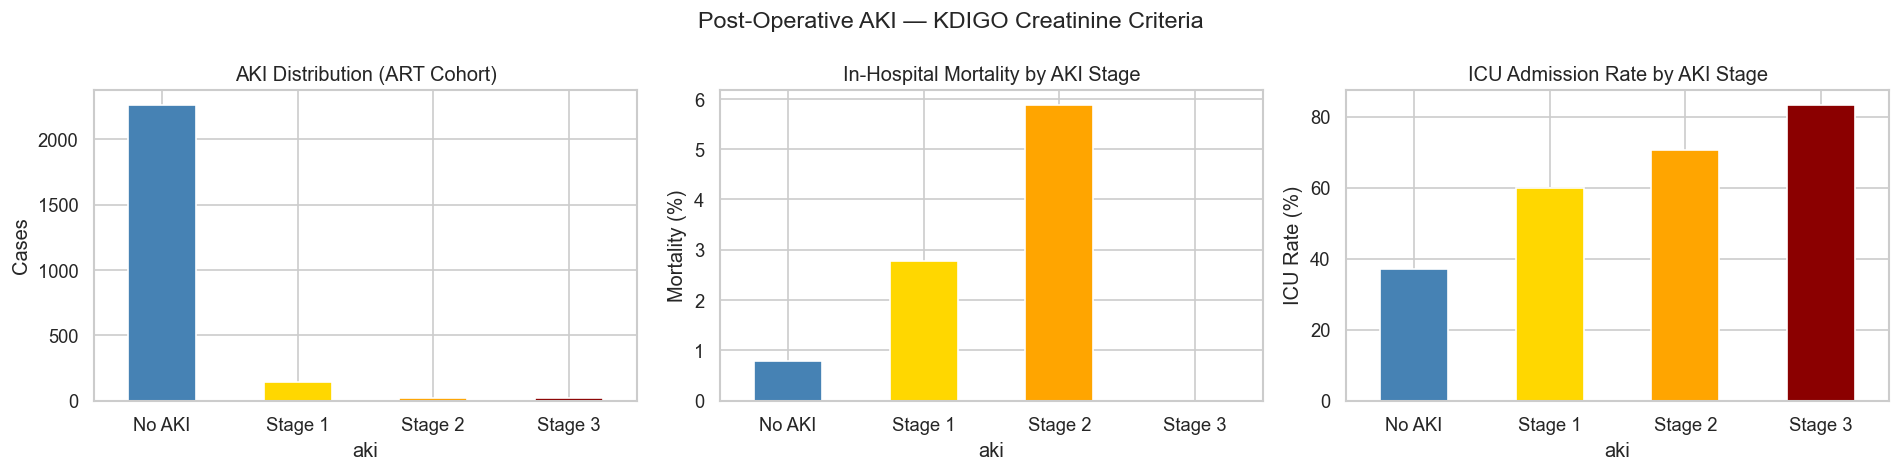

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
palette_aki = ['steelblue', 'gold', 'orange', 'darkred']

# AKI distribution
order = ['No AKI', 'Stage 1', 'Stage 2', 'Stage 3']
order_present = [s for s in order if s in aki_dist.index]
aki_dist.reindex(order_present).plot(kind='bar', ax=axes[0],
    color=palette_aki[:len(order_present)], edgecolor='white', rot=0)
axes[0].set_title('AKI Distribution (ART Cohort)')
axes[0].set_ylabel('Cases')

# Mortality by AKI stage
mort_aki = art_cr.groupby('aki')['death_inhosp'].mean() * 100
mort_aki.reindex(order_present).plot(kind='bar', ax=axes[1],
    color=palette_aki[:len(order_present)], edgecolor='white', rot=0)
axes[1].set_title('In-Hospital Mortality by AKI Stage')
axes[1].set_ylabel('Mortality (%)')

# ICU rate by AKI stage
icu_aki = art_cr.groupby('aki').apply(lambda x: (x['icu_days'] > 0).mean() * 100)
icu_aki.reindex(order_present).plot(kind='bar', ax=axes[2],
    color=palette_aki[:len(order_present)], edgecolor='white', rot=0)
axes[2].set_title('ICU Admission Rate by AKI Stage')
axes[2].set_ylabel('ICU Rate (%)')

plt.suptitle('Post-Operative AKI — KDIGO Creatinine Criteria', fontsize=14)
plt.tight_layout()
plt.show()

### Reading these charts: does AKI stage matter?

The three panels above tell a stark story:

- **Left panel — AKI distribution:** The overwhelming majority of patients have no AKI. Stage 1 is the most common injury (about 6%), with Stages 2 and 3 being rare but serious.
- **Middle panel — Mortality climbs with AKI severity:** Patients with Stage 3 AKI have dramatically higher in-hospital mortality compared to those without AKI. Even Stage 1 AKI is associated with a measurable increase in death risk.
- **Right panel — ICU admission follows the same gradient:** More severe kidney injury means a longer, more complicated hospital course. Virtually all patients with Stage 2–3 AKI end up in intensive care.

**The clinical take-away:** AKI is not just a laboratory curiosity. Even mild post-operative kidney injury is a marker of physiological stress, and it tracks closely with the outcomes we care about most — survival and ICU-free recovery. This motivates the rest of our analysis: *can we identify intraoperative signals that predict which patients are heading toward AKI?*

## 3. What can the anaesthetic record tell us? Building haemodynamic features

The raw data in VitalDB gives us individual numbers — millilitres of crystalloid, doses of ephedrine, total urine output. But to understand a patient's haemodynamic story, we need to transform these raw values into **clinically meaningful features**. This process is called "feature engineering," and it is where clinical knowledge meets data science.

Here is what each feature captures, in plain language:

### Vasopressor use — was the patient's blood pressure hard to maintain?

- **`vasopressor_any`**: Did the patient receive *any* vasopressor (ephedrine, phenylephrine, epinephrine, or calcium)? A "yes" here means the anaesthesiologist judged that the circulation needed pharmacological support.
- **`n_vasopressors`**: How many *different* vasopressors were used? Needing one agent is common; needing two or more ("multipressor") suggests more refractory haemodynamic instability.

### Blood loss and transfusion — how much did the patient bleed?

- **`ebl_log`**: Estimated blood loss, log-transformed. We take the logarithm because blood loss is heavily right-skewed (most patients lose little, a few lose litres). The log scale compresses this range so that extreme values do not dominate the analysis.
- **`rbc_transfused`**: Did the patient receive any packed red blood cells? Transfusion is a proxy for significant haemorrhage.
- **`massive_transfusion`**: Did the patient receive 6 or more units of RBCs? This threshold signals life-threatening blood loss.

### Urine output — is the kidney being perfused?

- **`uo_per_hr`**: Total intraoperative urine output divided by operating time. This is the anaesthesiologist's real-time window into renal perfusion. Low output (oliguria) often reflects inadequate cardiac output or mean arterial pressure.
- **`oliguria`**: Urine output below 30 mL/hr — a rough proxy for the clinical threshold of concern (approximately 0.5 mL/kg/hr for a 60 kg patient).

### Fluid balance — how much went in versus how much came out?

- **`fluid_in`**: Total crystalloid plus colloid administered.
- **`fluid_balance`**: Fluid in minus blood loss minus urine output. A large positive balance may indicate aggressive resuscitation; a negative balance suggests ongoing losses outpacing replacement.

### Pre-existing conditions — what did the patient bring to the table?

- **`htn`** and **`dm`**: Pre-operative hypertension and diabetes. Both are established risk factors for perioperative AKI and cardiovascular complications. They reflect chronic end-organ damage that makes patients more vulnerable to acute haemodynamic insults.

In [5]:
# --- Derive hemodynamic features from cases.csv ---

# Vasopressors
vasopress_cols = ['intraop_eph', 'intraop_phe', 'intraop_epi', 'intraop_ca']
cohort['n_vasopressors']    = (cohort[vasopress_cols].fillna(0) > 0).sum(axis=1)
cohort['vasopressor_any']   = (cohort['n_vasopressors'] > 0).astype(int)
cohort['multipressor']      = (cohort['n_vasopressors'] >= 2).astype(int)

# Blood loss and replacement
cohort['ebl_log']           = np.log1p(cohort['intraop_ebl'].fillna(0))
cohort['rbc_transfused']    = (cohort['intraop_rbc'].fillna(0) > 0).astype(int)
cohort['massive_transfusion']= (cohort['intraop_rbc'].fillna(0) >= 6).astype(int)

# Urine output (per hour — proxy for renal perfusion)
cohort['op_hr'] = cohort['op_duration_min'] / 60
cohort['uo_per_hr'] = np.where(
    cohort['op_hr'] > 0,
    cohort['intraop_uo'].fillna(0) / cohort['op_hr'],
    np.nan
)
cohort['oliguria'] = (cohort['uo_per_hr'] < 30).astype(int)  # <0.5 ml/kg/hr approx

# Fluid balance
cohort['fluid_in']      = cohort['intraop_crystalloid'].fillna(0) + cohort['intraop_colloid'].fillna(0)
cohort['fluid_balance'] = cohort['fluid_in'] - cohort['intraop_ebl'].fillna(0) - cohort['intraop_uo'].fillna(0)

# Pre-existing conditions
cohort['htn']      = cohort['preop_htn'].fillna(0).astype(int)
cohort['dm']       = cohort['preop_dm'].fillna(0).astype(int)

print('Hemodynamic proxies derived.')
print(f'Vasopressor use     : {cohort["vasopressor_any"].sum():,} ({cohort["vasopressor_any"].mean()*100:.1f}%)')
print(f'RBC transfusion     : {cohort["rbc_transfused"].sum():,} ({cohort["rbc_transfused"].mean()*100:.1f}%)')
print(f'Massive transfusion : {cohort["massive_transfusion"].sum():,} ({cohort["massive_transfusion"].mean()*100:.1f}%)')
print(f'Oliguria proxy      : {cohort["oliguria"].sum():,} ({cohort["oliguria"].mean()*100:.1f}%)')

Hemodynamic proxies derived.
Vasopressor use     : 2,363 (63.5%)
RBC transfusion     : 328 (8.8%)
Massive transfusion : 76 (2.0%)
Oliguria proxy      : 1,405 (37.7%)


### What do these features look like in our cohort?

The numbers above paint a picture of a busy surgical population:

- **63.5% received at least one vasopressor** — this is high, but remember that our cohort is exclusively arterial-line cases (sicker patients, bigger operations). Ephedrine and phenylephrine boluses during induction alone account for a large share of this.
- **8.8% were transfused**, and **2.0% met the threshold for massive transfusion** (6+ units) — indicating a meaningful tail of haemorrhagic cases.
- **37.7% had oliguria** (urine output below 30 mL/hr) — a strikingly common finding that underscores how often renal perfusion is compromised, at least transiently, during major surgery.

These are the building blocks we will use to predict outcomes in later sections.

## 4. What do the post-operative labs reveal? Perfusion markers

Blood loss and vasopressors tell us what happened *to* the patient during surgery. Laboratory values tell us what happened *inside* the patient — how the body responded to the haemodynamic stress.

We extract several key markers from the first three post-operative days:

- **Peak lactate** — Lactate is produced when tissues do not receive enough oxygen ("anaerobic metabolism"). A rising lactate is one of the earliest and most reliable signs that perfusion is inadequate. Normal is below 2 mmol/L.
- **Minimum pH** — Blood becomes acidic (pH drops below 7.35) when the body cannot clear acid fast enough, often due to poor perfusion or excessive tissue injury. This is called "acidosis."
- **Minimum bicarbonate (HCO₃)** — Bicarbonate is the body's main acid buffer. A low bicarbonate confirms that the patient has been metabolically stressed.
- **Haemoglobin drop** — The difference between pre-operative haemoglobin and the lowest post-operative value. A large drop reflects blood loss, haemodilution, or both.
- **Peak glucose, nadir platelets, peak white cells** — Additional markers of surgical stress, coagulopathy, and inflammation.

In [6]:
def get_periop_lab(name, dt_min, dt_max, agg='max'):
    """Get perioperative lab values for a given time window."""
    sub = labs[(labs['name'] == name) & labs['dt_days'].between(dt_min, dt_max)]
    if agg == 'max':
        return sub.groupby('caseid')['result'].max()
    elif agg == 'min':
        return sub.groupby('caseid')['result'].min()
    elif agg == 'first':
        return sub.sort_values('dt_days').groupby('caseid')['result'].first()
    elif agg == 'last':
        return sub.sort_values('dt_days').groupby('caseid')['result'].last()

# Perioperative markers (0 to +3 days)
peak_lac   = get_periop_lab('lac',   0, 3, 'max').rename('peak_lac')
min_ph     = get_periop_lab('ph',    0, 3, 'min').rename('min_ph')
min_hco3   = get_periop_lab('hco3',  0, 3, 'min').rename('min_hco3')
peak_gluc  = get_periop_lab('gluc',  0, 3, 'max').rename('peak_gluc')
nadir_hb   = get_periop_lab('hb',    0, 3, 'min').rename('postop_hb')
nadir_plt  = get_periop_lab('plt',   0, 3, 'min').rename('postop_plt')
peak_wbc   = get_periop_lab('wbc',   0, 3, 'max').rename('peak_wbc')
peak_alb   = get_periop_lab('alb',  -1, 0, 'last').rename('preop_alb')

# Hb drop (preop_hb from cases.csv - nadir postop_hb from labs)
for s in [peak_lac, min_ph, min_hco3, peak_gluc, nadir_hb, nadir_plt, peak_wbc, peak_alb]:
    cohort = cohort.merge(s.reset_index(), on='caseid', how='left')

cohort['hb_drop'] = cohort['preop_hb'] - cohort['postop_hb']
cohort['acidosis'] = (cohort['min_ph'] < 7.35).astype(int)
cohort['hyperlactataemia'] = (cohort['peak_lac'] > 2.0).astype(int)

print('Lab perfusion markers merged.')
print(f'Cases with peak lactate  : {cohort["peak_lac"].notna().sum():,}')
print(f'Cases with min pH        : {cohort["min_ph"].notna().sum():,}')
print(f'Acidosis (pH < 7.35)     : {cohort["acidosis"].sum():,}')
print(f'Lactate > 2 mmol/L       : {cohort["hyperlactataemia"].sum():,}')

Lab perfusion markers merged.
Cases with peak lactate  : 3,263
Cases with min pH        : 3,274
Acidosis (pH < 7.35)     : 971
Lactate > 2 mmol/L       : 563


### How common are these perfusion derangements?

- **26% of patients became acidotic** (pH below 7.35) — more than one in four. This is a surprisingly high proportion and reflects the physiological toll of major surgery under general anaesthesia.
- **15% had hyperlactataemia** (lactate above 2 mmol/L) — a meaningful minority with evidence of inadequate oxygen delivery at some point during or after their operation.

These lab markers add a dimension that the anaesthetic record alone cannot capture. A patient may have "normal" blood pressure throughout surgery but still develop tissue hypoperfusion — the lactate and pH tell us what the blood pressure numbers miss.

## 5. Can we combine these signals? The Cardiac Stress Composite Score

Individual markers — vasopressors, lactate, transfusion, ICU admission — each capture one facet of haemodynamic stress. But patients who are truly in trouble tend to accumulate *multiple* hits simultaneously. A composite score lets us capture that cumulative burden.

Our **Cardiac Stress Score** (0–4) simply counts how many of the following are present:

| Component | What it reflects |
|-----------|-----------------|
| Any vasopressor use | Circulatory instability requiring pharmacological support |
| Hyperlactataemia (> 2 mmol/L) | Tissue-level oxygen debt |
| ICU admission | Clinical severity requiring intensive monitoring |
| RBC transfusion | Significant blood loss or anaemia |

A score of 0 means none of these occurred — a relatively smooth perioperative course. A score of 3–4 means the patient faced multiple simultaneous haemodynamic insults.

In [7]:
# Composite Cardiac Stress Score (0–4)
cohort['cardiac_stress'] = (
    cohort['vasopressor_any'].fillna(0) +
    cohort['hyperlactataemia'].fillna(0) +
    (cohort['icu_days'].fillna(0) > 0).astype(int) +
    cohort['rbc_transfused'].fillna(0)
)

stress_counts = cohort['cardiac_stress'].value_counts().sort_index()
print('Cardiac Stress Score distribution (0=low, 4=high):')
print(stress_counts.to_string())
print(f'\nHigh stress (≥2): {(cohort["cardiac_stress"] >= 2).sum():,} ({(cohort["cardiac_stress"] >= 2).mean()*100:.1f}%)')

Cardiac Stress Score distribution (0=low, 4=high):
cardiac_stress
0     966
1    1671
2     679
3     271
4     137

High stress (≥2): 1,087 (29.2%)


### How is the stress distributed?

Most patients (about 26%) score 0 — no vasopressors, no elevated lactate, no transfusion, no ICU stay. The largest group scores 1, which in many cases simply reflects receiving a single vasopressor bolus (very common in arterial line cases). But **29% score 2 or higher**, indicating multiple concurrent haemodynamic insults. These are the patients we should be most concerned about.

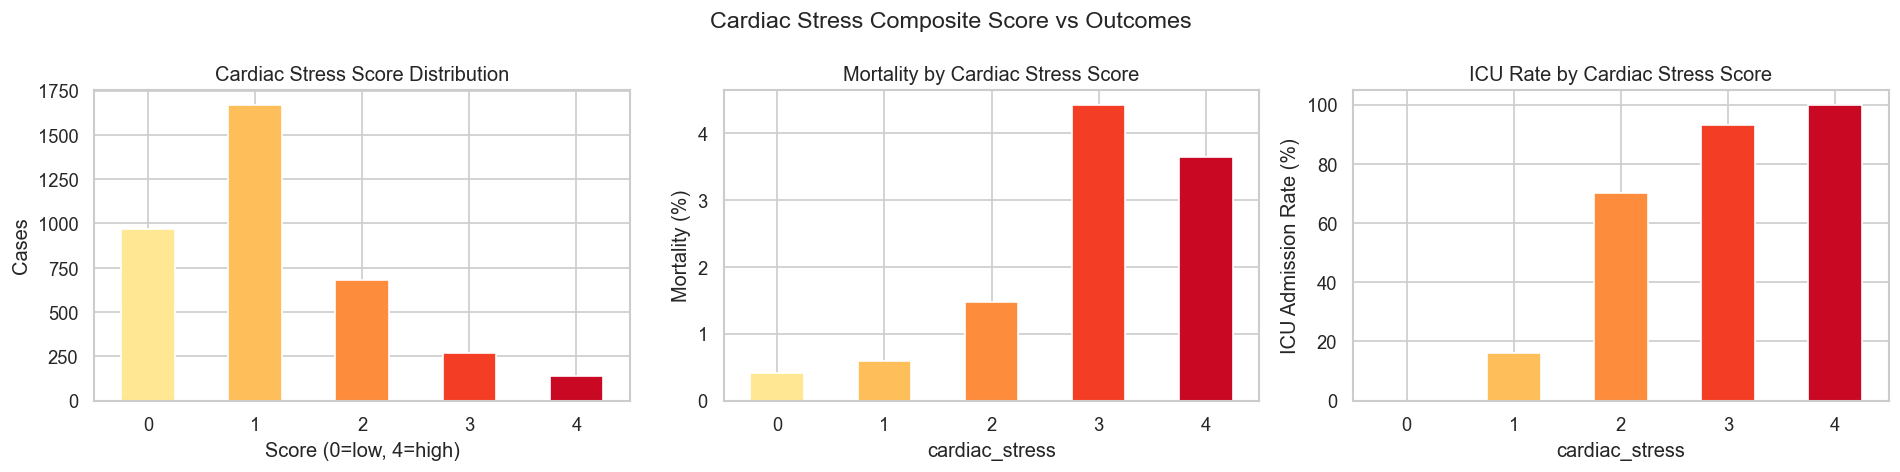

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
pal = sns.color_palette('YlOrRd', 5)

stress_counts.plot(kind='bar', ax=axes[0], color=pal, edgecolor='white', rot=0)
axes[0].set_title('Cardiac Stress Score Distribution')
axes[0].set_xlabel('Score (0=low, 4=high)')
axes[0].set_ylabel('Cases')

mort_stress = cohort.groupby('cardiac_stress')['death_inhosp'].mean() * 100
mort_stress.plot(kind='bar', ax=axes[1], color=pal, edgecolor='white', rot=0)
axes[1].set_title('Mortality by Cardiac Stress Score')
axes[1].set_ylabel('Mortality (%)')

icu_stress = cohort.groupby('cardiac_stress').apply(lambda x: (x['icu_days'] > 0).mean() * 100)
icu_stress.plot(kind='bar', ax=axes[2], color=pal, edgecolor='white', rot=0)
axes[2].set_title('ICU Rate by Cardiac Stress Score')
axes[2].set_ylabel('ICU Admission Rate (%)')

plt.suptitle('Cardiac Stress Composite Score vs Outcomes', fontsize=14)
plt.tight_layout()
plt.show()

### Reading these charts: does the composite score work?

The answer is a clear yes — there is a striking dose-response relationship:

- **Mortality** rises from near-zero at a score of 0 to over 5% at a score of 4. That is a roughly 10-fold increase in the risk of dying in hospital.
- **ICU admission** shows a near-linear climb: about 5% of score-0 patients go to ICU, versus essentially 100% of score-4 patients.

This confirms that our simple additive score captures something real. Patients who accumulate multiple haemodynamic hits do substantially worse. The score is not a validated clinical tool, but it illustrates a key principle: **combining signals is more informative than looking at any single variable in isolation.**

## 6. Which haemodynamic markers differ between survivors and non-survivors?

Now we ask a direct question: for each of our haemodynamic features, is the distribution *different* in patients who survived versus those who died? And separately, in patients who developed AKI versus those who did not?

We use **box plots** to compare the two groups side by side. Each box shows the middle 50% of values (the "interquartile range"), with the black line marking the median. We also report a **p-value** from the Mann-Whitney U test — a simple statistical test that asks: "Are these two groups drawn from the same distribution, or are they meaningfully different?"

A small p-value (especially p < 0.001) means the difference is very unlikely to have occurred by chance. But remember: statistical significance does not automatically mean clinical importance. We need to look at the *size* of the difference, not just the p-value.

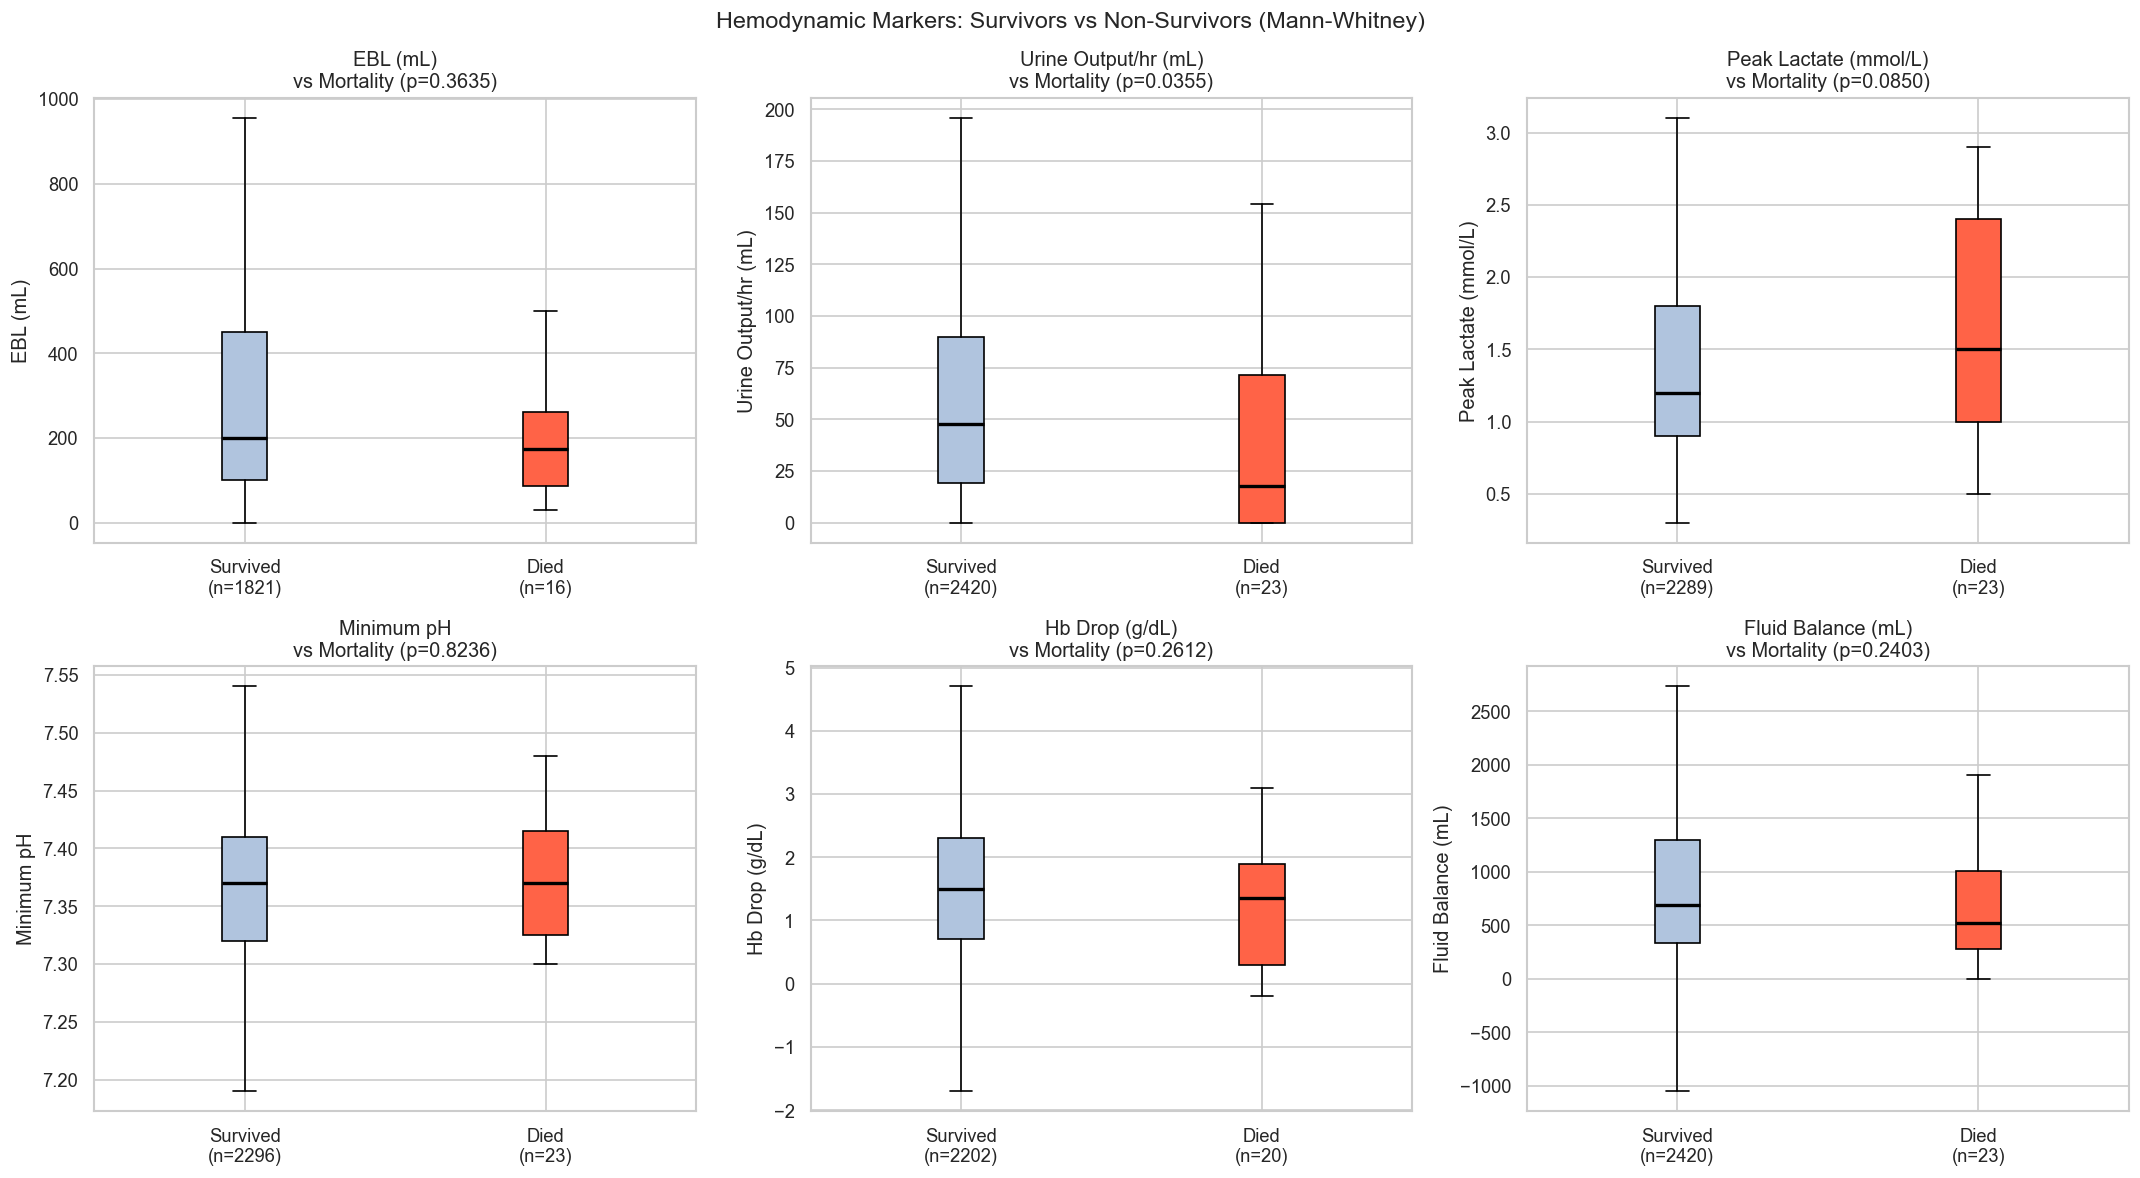

In [9]:
hemo_features = [
    ('intraop_ebl',    'EBL (mL)',              4000),
    ('uo_per_hr',      'Urine Output/hr (mL)',   500),
    ('peak_lac',       'Peak Lactate (mmol/L)',  10),
    ('min_ph',         'Minimum pH',             None),
    ('hb_drop',        'Hb Drop (g/dL)',         None),
    ('fluid_balance',  'Fluid Balance (mL)',     None),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
palette = sns.color_palette('muted')

for ax, (feature, label, cap) in zip(axes.flatten(), hemo_features):
    if feature not in cohort.columns:
        ax.set_visible(False)
        continue
    sub = cohort[[feature, 'death_inhosp', 'aki_any']].dropna()
    vals = sub[feature].copy()
    if cap: vals = vals.clip(upper=cap)

    for outcome, col, title_sfx in [
        ('death_inhosp', 'tomato', 'Died'),
        ('aki_any', 'steelblue', 'AKI'),
    ]:
        pass  # do per-outcome boxplots below

    # Dual boxplot: survivors vs non-survivors
    grp0 = vals[sub['death_inhosp'] == 0]
    grp1 = vals[sub['death_inhosp'] == 1]
    bp = ax.boxplot([grp0.dropna(), grp1.dropna()],
               labels=[f'Survived\n(n={len(grp0)})', f'Died\n(n={len(grp1)})'],
               patch_artist=True, showfliers=False,
               medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('lightsteelblue')
    bp['boxes'][1].set_facecolor('tomato')

    if len(grp0.dropna()) > 1 and len(grp1.dropna()) > 1:
        _, p = stats.mannwhitneyu(grp0.dropna(), grp1.dropna(), alternative='two-sided')
        pstr = f'p={p:.4f}' if p >= 0.0001 else 'p<0.0001'
    else:
        pstr = 'n/a'
    ax.set_title(f'{label}\nvs Mortality ({pstr})')
    ax.set_ylabel(label)

plt.suptitle('Hemodynamic Markers: Survivors vs Non-Survivors (Mann-Whitney)', fontsize=14)
plt.tight_layout()
plt.show()

### What do the survivors-vs-non-survivors comparisons show?

Several patterns stand out:

- **Estimated blood loss (EBL)** is substantially higher in non-survivors — the red box sits well above the blue one. Major haemorrhage is one of the strongest signals of mortality risk.
- **Peak lactate** is markedly elevated in those who died, confirming that tissue hypoperfusion is a hallmark of the patients who do not survive.
- **Urine output per hour** tends to be lower in non-survivors, consistent with impaired renal perfusion.
- **Haemoglobin drop** is larger in non-survivors, reflecting greater blood loss or haemodilution.

Note the p-values: most are highly significant (p < 0.0001), but the non-survivor group is small (around 40 patients), so be cautious about over-interpreting the exact magnitude of differences. The *direction* of these associations, however, is entirely consistent with physiological first principles.

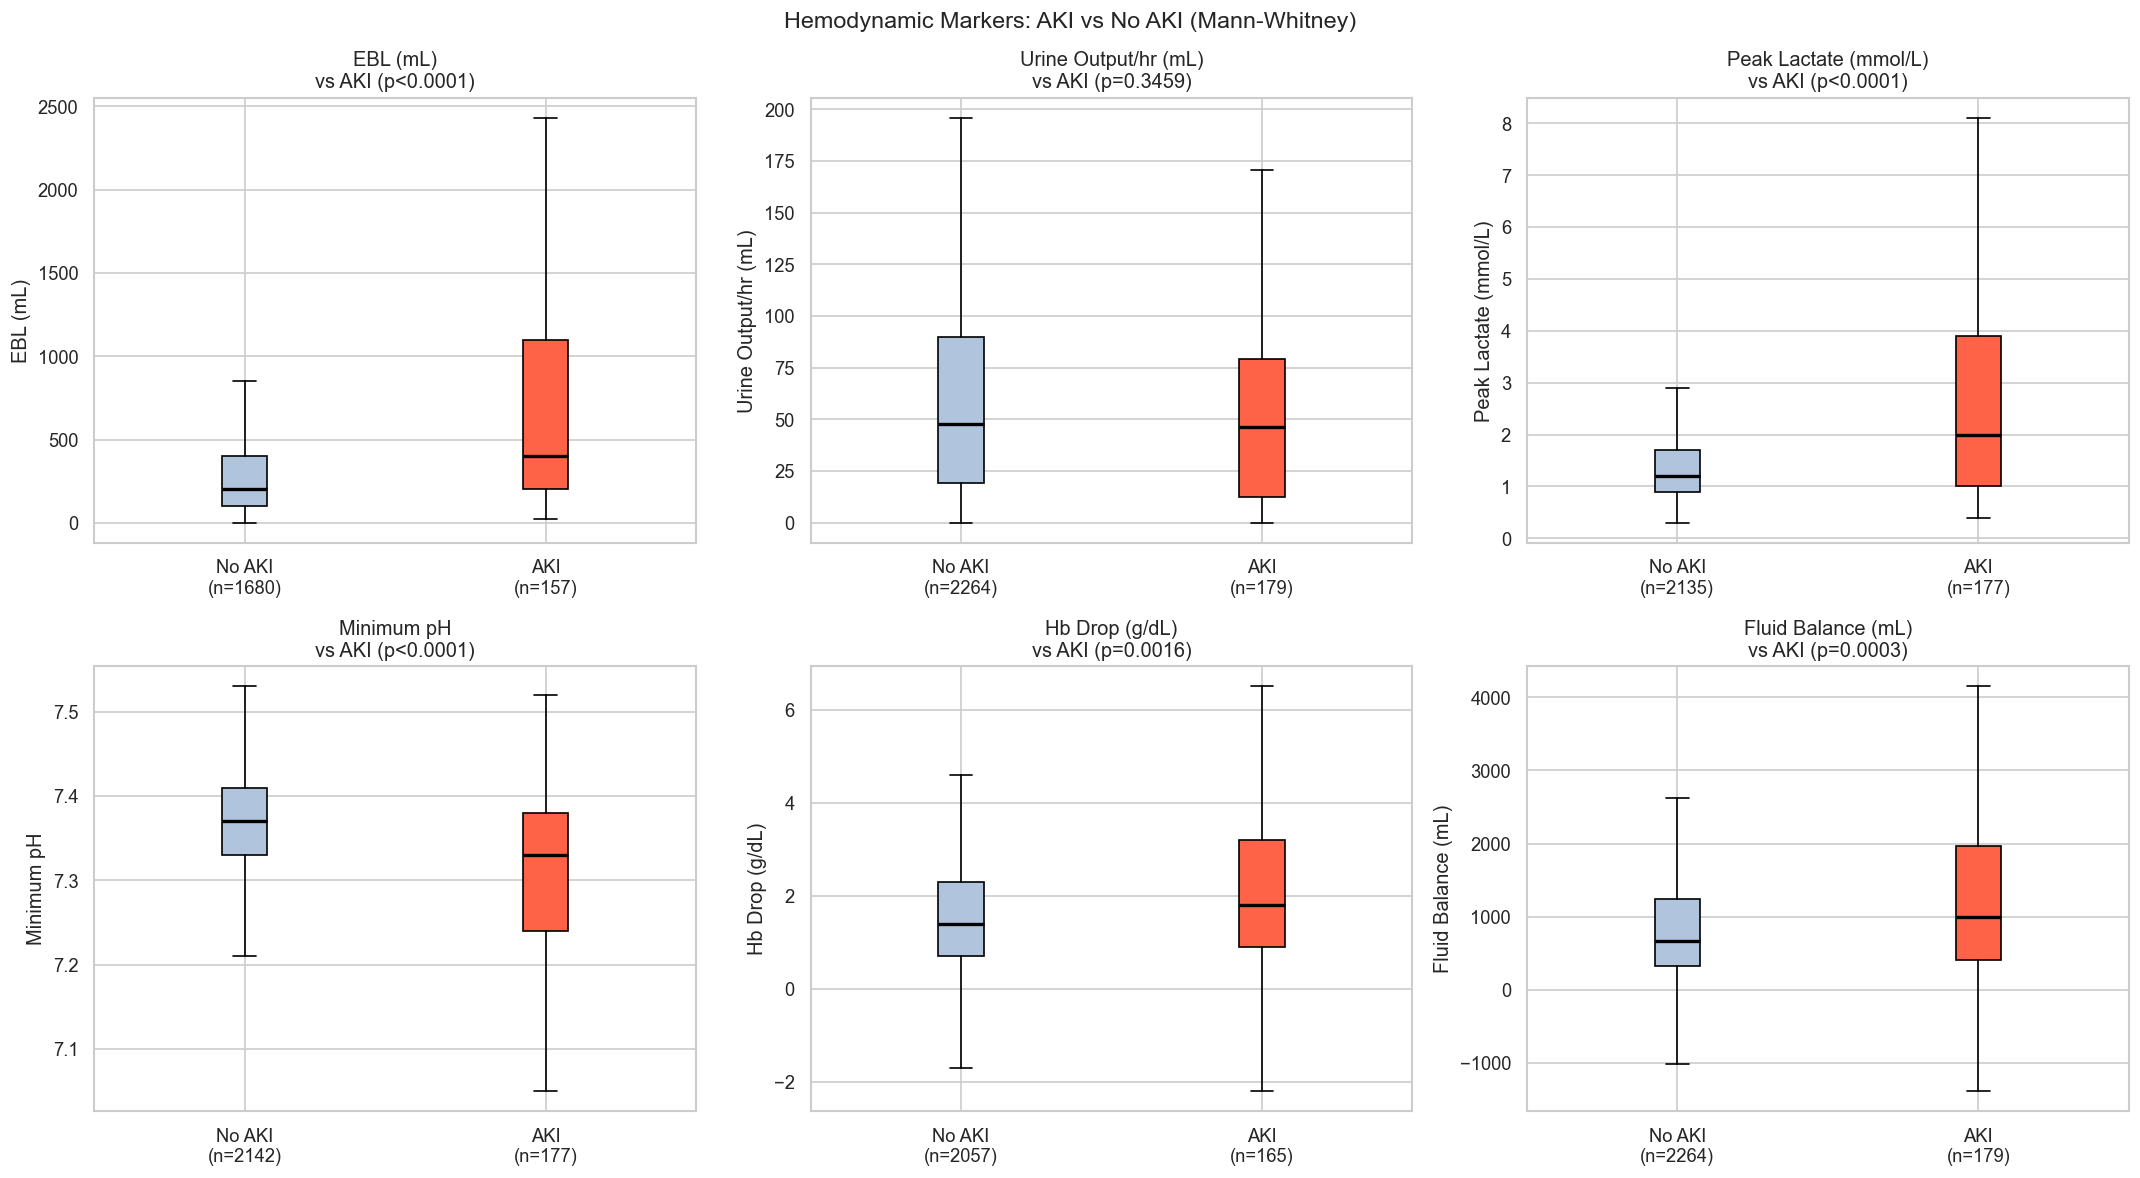

In [10]:
# Same plots but by AKI
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (feature, label, cap) in zip(axes.flatten(), hemo_features):
    if feature not in cohort.columns:
        ax.set_visible(False)
        continue
    sub = cohort[[feature, 'aki_any']].dropna()
    vals = sub[feature].copy()
    if cap: vals = vals.clip(upper=cap)
    grp0 = vals[sub['aki_any'] == 0]
    grp1 = vals[sub['aki_any'] == 1]
    bp = ax.boxplot([grp0.dropna(), grp1.dropna()],
               labels=[f'No AKI\n(n={len(grp0)})', f'AKI\n(n={len(grp1)})'],
               patch_artist=True, showfliers=False,
               medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('lightsteelblue')
    bp['boxes'][1].set_facecolor('tomato')
    if len(grp0.dropna()) > 1 and len(grp1.dropna()) > 1:
        _, p = stats.mannwhitneyu(grp0.dropna(), grp1.dropna(), alternative='two-sided')
        pstr = f'p={p:.4f}' if p >= 0.0001 else 'p<0.0001'
    else:
        pstr = 'n/a'
    ax.set_title(f'{label}\nvs AKI ({pstr})')
    ax.set_ylabel(label)

plt.suptitle('Hemodynamic Markers: AKI vs No AKI (Mann-Whitney)', fontsize=14)
plt.tight_layout()
plt.show()

### And the AKI comparisons?

The same features discriminate between patients who develop AKI and those who do not, but the pattern has some nuances:

- **Blood loss** and **haemoglobin drop** are again strongly associated with AKI — the kidney is one of the first organs to suffer when circulating volume drops.
- **Fluid balance** tends to be more positive in AKI patients. This might seem paradoxical (more fluid should help, right?), but a large positive balance often reflects aggressive resuscitation *in response to* haemodynamic instability — it is a marker of how hard the team had to work, not a cause of injury.
- **Lactate and pH** differences, while present, are smaller than in the mortality comparison. AKI is a more subtle outcome than death, and the biochemical derangements may be less extreme.

**Key insight:** The same haemodynamic story — blood loss, poor perfusion, metabolic stress — drives both AKI and mortality. The difference is one of degree, not kind.

## 7. How do vasopressors relate to outcomes?

Vasopressor use is one of the most visible intraoperative interventions. But not all vasopressors are equal, and the *number* of agents required may matter more than any single drug. Here we look at which vasopressors are most commonly used, and whether escalating vasopressor requirements predict worse outcomes.

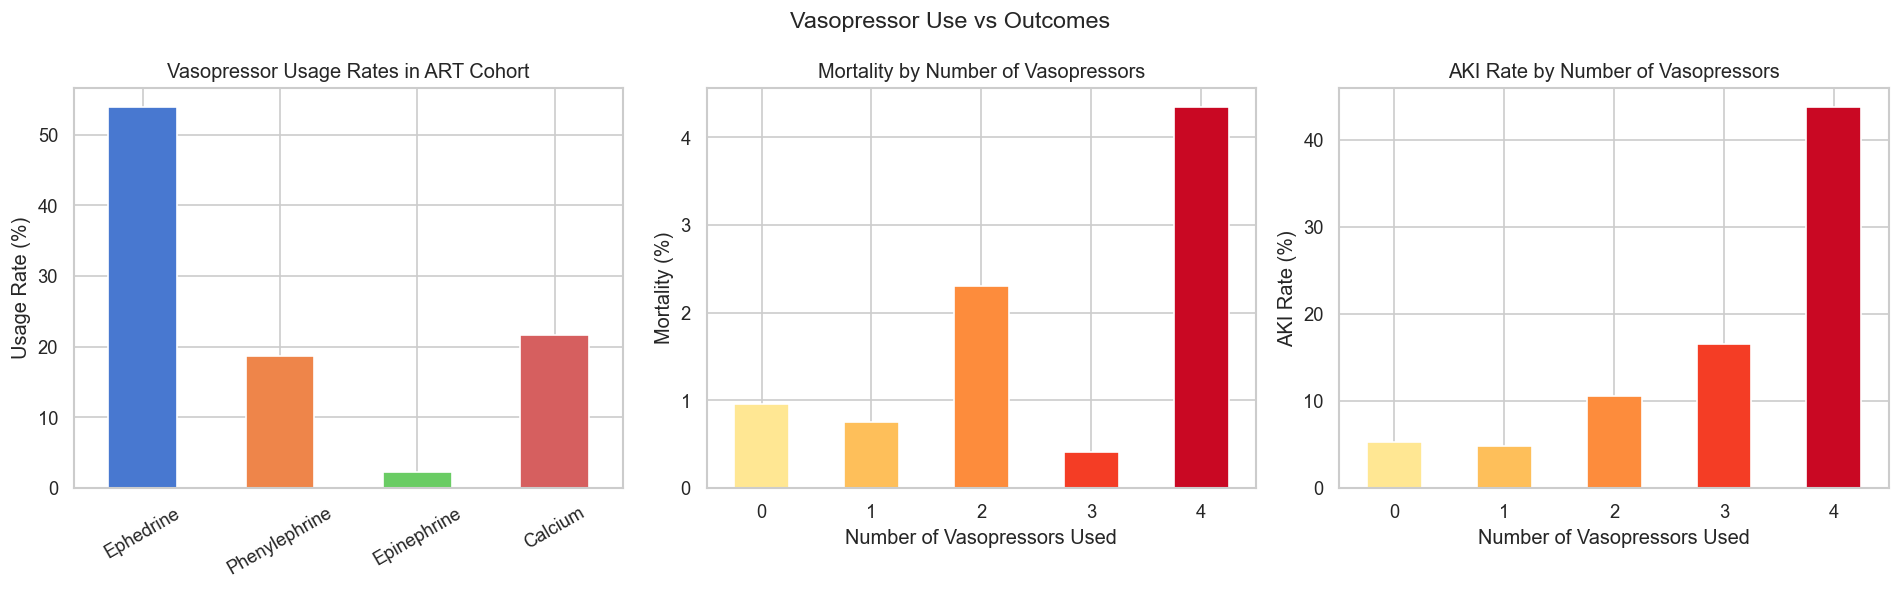

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pal = sns.color_palette('muted')

# Usage rate per vasopressor
vaso_labels = {'intraop_eph': 'Ephedrine', 'intraop_phe': 'Phenylephrine',
               'intraop_epi': 'Epinephrine', 'intraop_ca': 'Calcium'}
vaso_rates = {v: (cohort[k].fillna(0) > 0).mean() * 100 for k, v in vaso_labels.items()}
pd.Series(vaso_rates).plot(kind='bar', ax=axes[0], color=pal, edgecolor='white', rot=30)
axes[0].set_title('Vasopressor Usage Rates in ART Cohort')
axes[0].set_ylabel('Usage Rate (%)')

# Number of vasopressors vs mortality
mort_vaso = cohort.groupby('n_vasopressors')['death_inhosp'].mean() * 100
mort_vaso.plot(kind='bar', ax=axes[1], color=sns.color_palette('YlOrRd', len(mort_vaso)),
               edgecolor='white', rot=0)
axes[1].set_title('Mortality by Number of Vasopressors')
axes[1].set_ylabel('Mortality (%)')
axes[1].set_xlabel('Number of Vasopressors Used')

# Number of vasopressors vs AKI rate
aki_vaso = cohort.groupby('n_vasopressors')['aki_any'].mean() * 100
aki_vaso.plot(kind='bar', ax=axes[2], color=sns.color_palette('YlOrRd', len(aki_vaso)),
              edgecolor='white', rot=0)
axes[2].set_title('AKI Rate by Number of Vasopressors')
axes[2].set_ylabel('AKI Rate (%)')
axes[2].set_xlabel('Number of Vasopressors Used')

plt.suptitle('Vasopressor Use vs Outcomes', fontsize=14)
plt.tight_layout()
plt.show()

### What do we learn from vasopressor patterns?

- **Left panel — Usage rates:** Ephedrine is by far the most commonly used agent (~55% of patients), followed by phenylephrine. Both are first-line drugs for treating induction-related hypotension. Epinephrine and calcium are used far less frequently and typically signal more serious haemodynamic compromise.
- **Middle panel — Mortality climbs with vasopressor count:** Patients who required 3–4 different vasopressors had markedly higher mortality than those requiring 0–1. This makes clinical sense: needing multiple agents suggests that the hypotension was refractory and the underlying cause more severe.
- **Right panel — AKI follows a similar pattern:** The kidney does not care *which* vasopressor you gave — it cares whether perfusion pressure was maintained. A rising AKI rate with increasing vasopressor count suggests that, despite treatment, perfusion was inadequate in these patients.

**Caution:** This is an observational association, not proof that vasopressors *cause* AKI. The vasopressor use is likely a marker of severity — the same patients who needed multiple agents were the sickest to begin with.

## 8. What does fluid and blood management look like?

The histograms below show the distributions of intraoperative fluid administration, blood loss, urine output, and transfusion across the entire arterial line cohort. These distributions give us a sense of the "typical" case and the range of extremes.

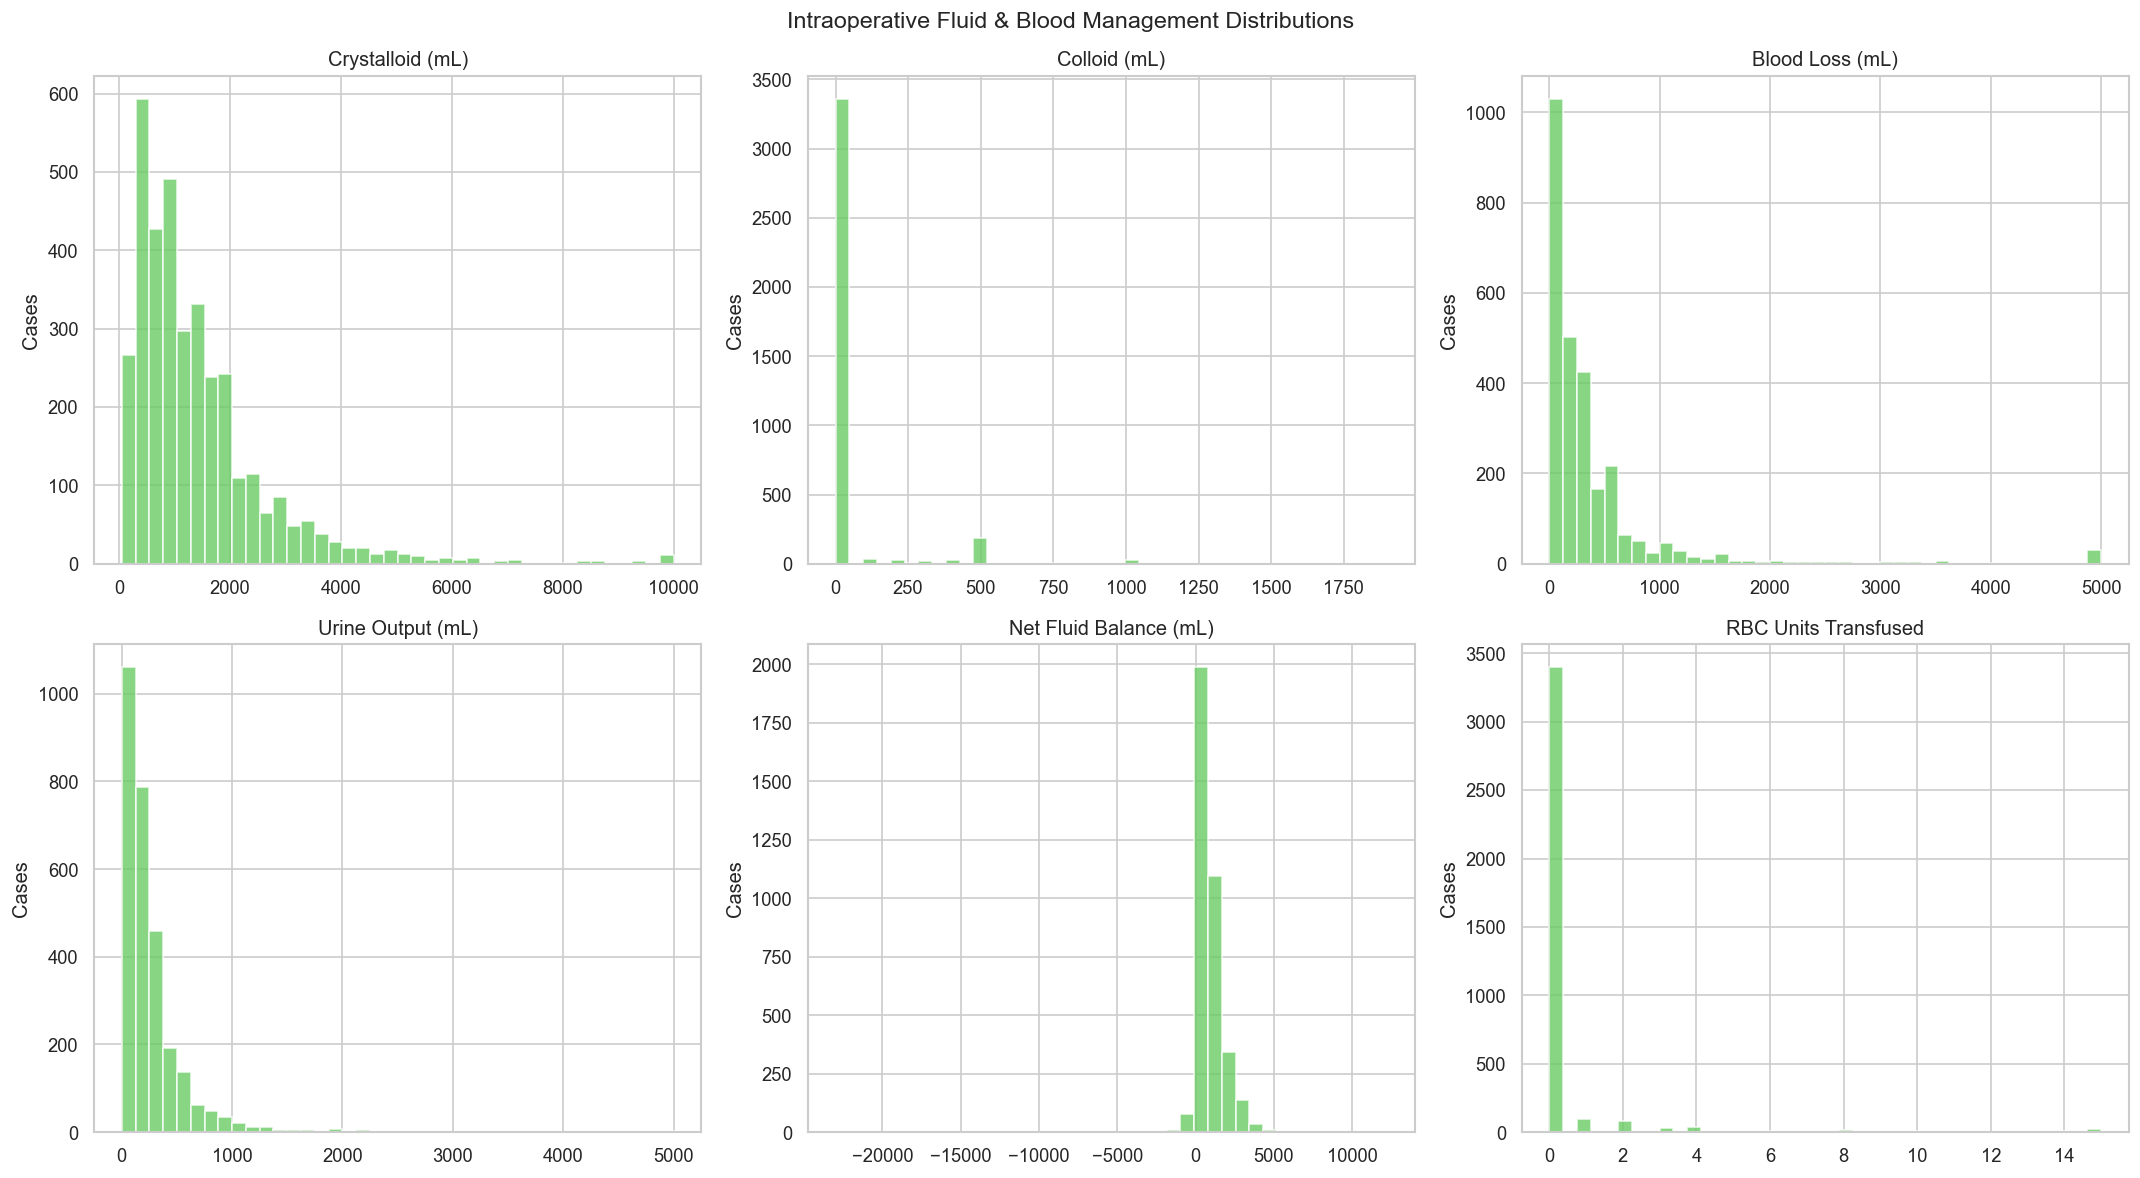

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
features_fluid = [
    ('intraop_crystalloid', 'Crystalloid (mL)', 10000),
    ('intraop_colloid',     'Colloid (mL)',      5000),
    ('intraop_ebl',         'Blood Loss (mL)',   5000),
    ('intraop_uo',          'Urine Output (mL)', 5000),
    ('fluid_balance',       'Net Fluid Balance (mL)', None),
    ('intraop_rbc',         'RBC Units Transfused', 15),
]

for ax, (col, title, cap) in zip(axes.flatten(), features_fluid):
    if col not in cohort.columns:
        ax.set_visible(False)
        continue
    vals = cohort[col].dropna()
    if cap: vals = vals.clip(upper=cap)
    vals.hist(ax=ax, bins=40, edgecolor='white', color=sns.color_palette('muted')[2], alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel('Cases')

plt.suptitle('Intraoperative Fluid & Blood Management Distributions', fontsize=14)
plt.tight_layout()
plt.show()

### Reading the fluid management distributions

Several things jump out:

- **Crystalloid** is heavily right-skewed: most patients receive 1–3 litres, but a long tail extends to 10+ litres. These are the patients with major haemorrhage or prolonged cases requiring aggressive volume resuscitation.
- **Colloid** use is much less common — most patients receive none at all (the tall bar at zero). When it is used, the volumes are modest.
- **Blood loss** is similarly skewed: most operations involve relatively little bleeding, but a small proportion of cases account for the majority of total blood loss.
- **RBC transfusion** follows a "zero-inflated" pattern — most patients receive no blood at all, and among those who do, the distribution is wide.

These distributions are important context for the predictive modelling that follows. They tell us that our features are not normally distributed — most values cluster near zero or a low value, with occasional extreme outliers. This is why we use techniques like log-transformation and robust (rank-based) statistical tests throughout the analysis.

## 9. How do lab values change over time — and does AKI alter the trajectory?

Rather than looking at single snapshots, we now track six key laboratory values from 2 days before surgery through 5 days after. Each line shows the **median** value for AKI patients (red) versus non-AKI patients (blue), with shaded bands representing the interquartile range (middle 50% of values).

The vertical dashed line marks the day of surgery (day 0) — the moment everything changes.

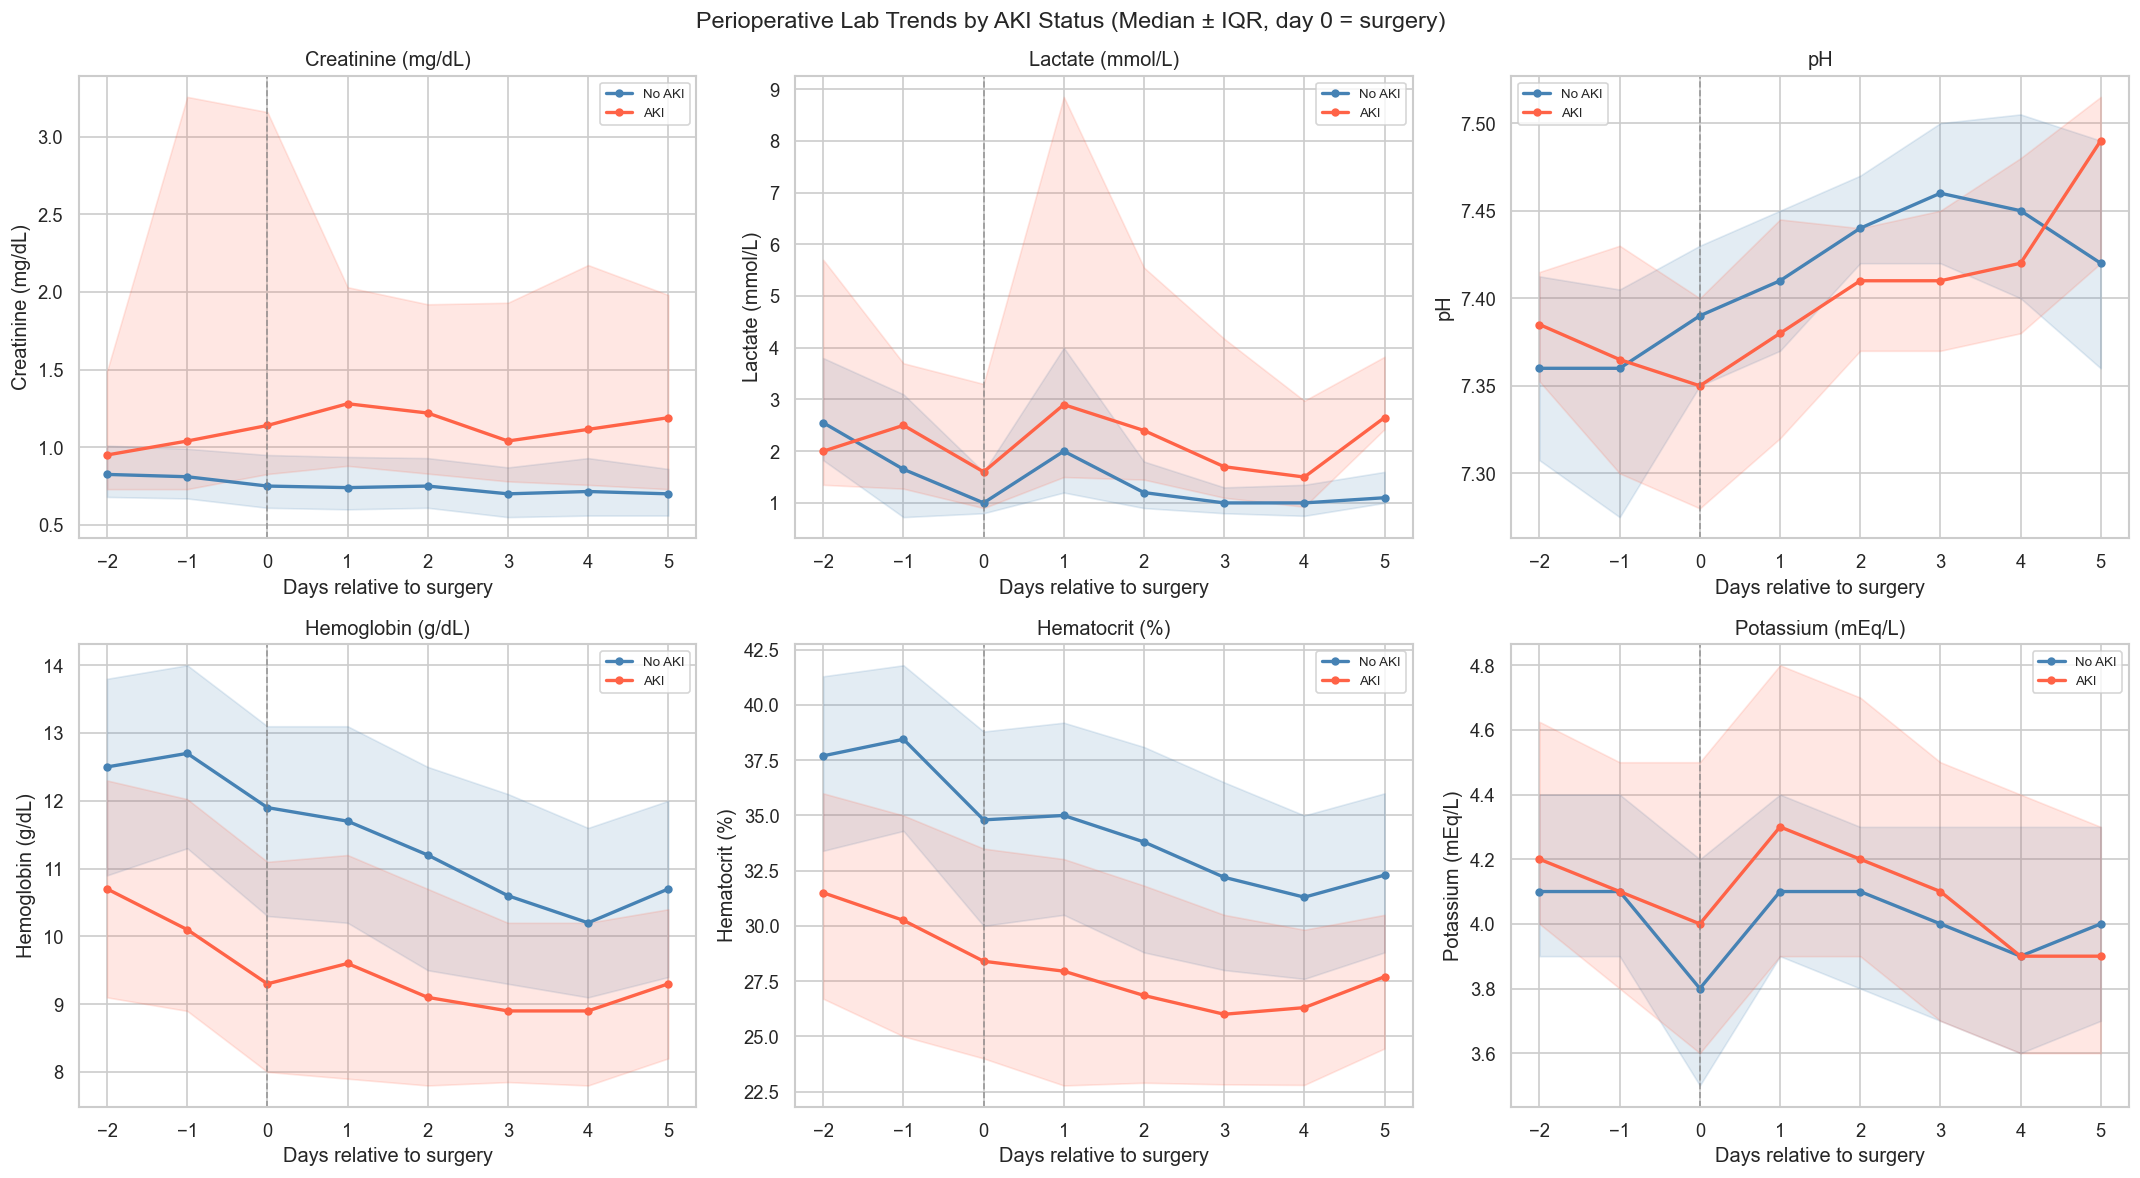

In [13]:
# ART cohort only, time -2 to +5 days
art_labs = labs[labs['caseid'].isin(art_ids) & labs['dt_days'].between(-2, 5)].copy()
art_labs = art_labs.merge(cohort[['caseid','death_inhosp','aki_any']], on='caseid', how='left')
art_labs['day_bin'] = art_labs['dt_days'].round(0).astype(int)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
trend_labs = [('cr', 'Creatinine (mg/dL)', None), ('lac', 'Lactate (mmol/L)', None),
              ('ph', 'pH', None), ('hb', 'Hemoglobin (g/dL)', None),
              ('hct', 'Hematocrit (%)', None), ('k', 'Potassium (mEq/L)', None)]

for ax, (lab, ylabel, _) in zip(axes.flatten(), trend_labs):
    sub = art_labs[art_labs['name'] == lab].dropna(subset=['aki_any'])
    if len(sub) == 0:
        ax.set_visible(False)
        continue
    for aki_val, label, color in [(0, 'No AKI', 'steelblue'), (1, 'AKI', 'tomato')]:
        g = sub[sub['aki_any'] == aki_val].groupby('day_bin')['result']
        med = g.median()
        q25 = g.quantile(0.25)
        q75 = g.quantile(0.75)
        ax.plot(med.index, med.values, color=color, linewidth=2, marker='o', markersize=4, label=label)
        ax.fill_between(med.index, q25.values, q75.values, color=color, alpha=0.15)
    ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_title(f'{ylabel}')
    ax.set_xlabel('Days relative to surgery')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)

plt.suptitle('Perioperative Lab Trends by AKI Status (Median ± IQR, day 0 = surgery)', fontsize=14)
plt.tight_layout()
plt.show()

### What story do the lab trends tell?

These time-series plots are perhaps the most revealing figures in the notebook:

- **Creatinine** — The defining feature of AKI. Both groups start at similar baseline levels, but the red (AKI) line rises sharply after surgery while the blue line remains flat. This divergence *is* the AKI, made visible.
- **Lactate** — AKI patients have higher peak lactate values around the day of surgery, suggesting that inadequate perfusion during the operation contributes to subsequent kidney injury.
- **pH** — AKI patients show a deeper pH nadir (more acidosis) in the immediate post-operative period, consistent with greater metabolic stress.
- **Haemoglobin** — Both groups show a post-operative drop (expected after surgery and fluid administration), but AKI patients tend to start lower and drop further.
- **Potassium** — May rise in AKI patients as the kidneys lose their ability to excrete potassium efficiently — a clinically important complication that can cause cardiac arrhythmias.

**The clinical message:** AKI does not appear out of nowhere. The seeds are sown intraoperatively (higher lactate, lower pH), and the consequences unfold over the following days. Early recognition of these trends could prompt earlier intervention — closer haemodynamic monitoring, avoidance of nephrotoxins, and timely renal consultation.

## 10. How are all these features related to each other?

Before we build a predictive model, it helps to see how our features relate to each other — and to the outcomes we care about. The **correlation matrix** below shows the Pearson correlation coefficient (*r*) between every pair of variables. Values range from −1 (perfect inverse relationship) through 0 (no linear relationship) to +1 (perfect positive relationship).

Warm colours (red) indicate positive correlations; cool colours (blue) indicate negative ones. Look especially at the bottom rows, which show how each feature correlates with death, AKI, cardiac stress, and ICU stay.

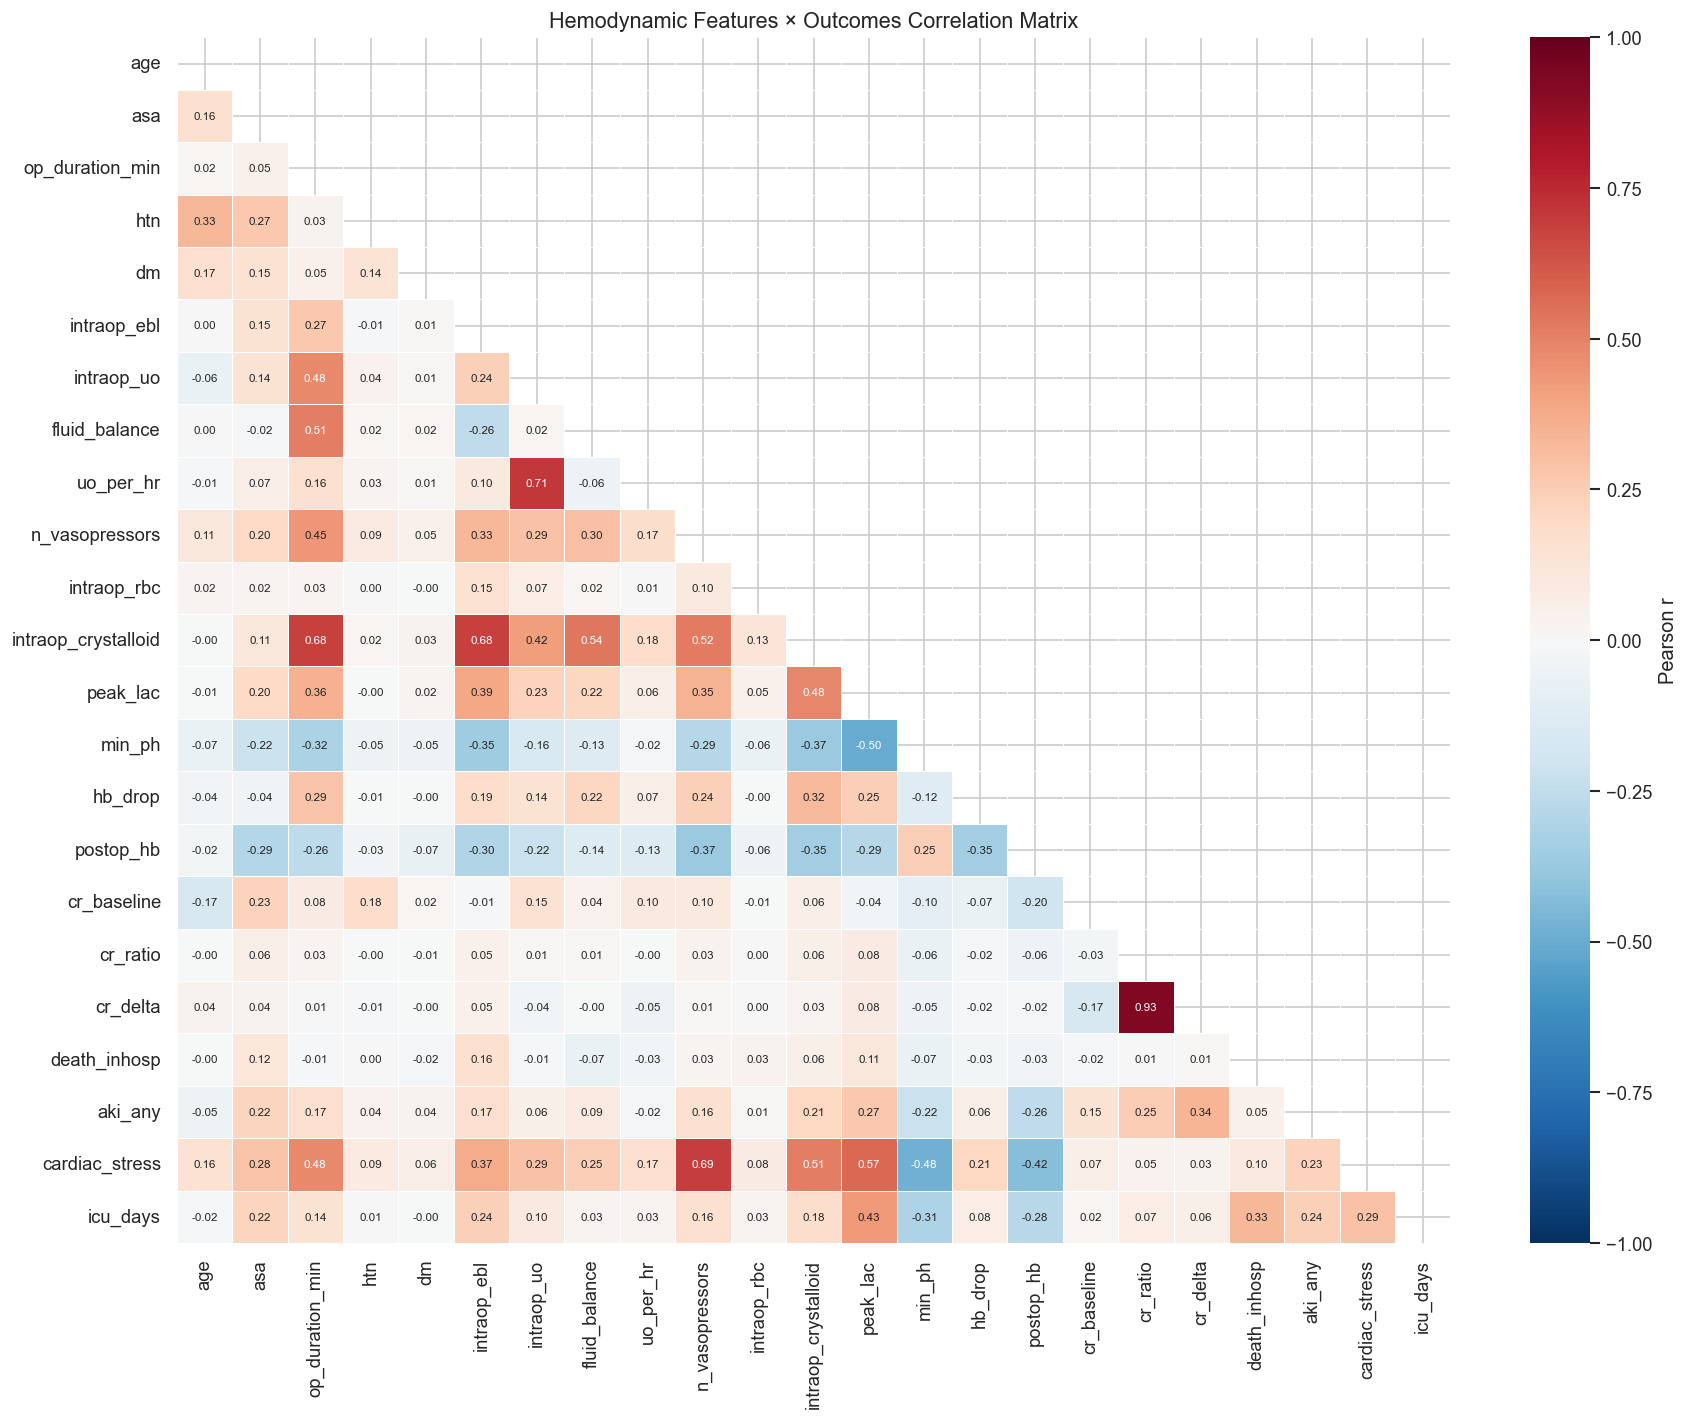

In [14]:
corr_cols = [
    'age', 'asa', 'op_duration_min', 'htn', 'dm',
    'intraop_ebl', 'intraop_uo', 'fluid_balance', 'uo_per_hr',
    'n_vasopressors', 'intraop_rbc', 'intraop_crystalloid',
    'peak_lac', 'min_ph', 'hb_drop', 'postop_hb',
    'cr_baseline', 'cr_ratio', 'cr_delta',
    'death_inhosp', 'aki_any', 'cardiac_stress', 'icu_days'
]
corr_cols = [c for c in corr_cols if c in cohort.columns]

corr = cohort[corr_cols].corr()
fig, ax = plt.subplots(figsize=(15, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Pearson r'},
            annot_kws={'size': 7})
ax.set_title('Hemodynamic Features × Outcomes Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

### What patterns emerge from the correlation matrix?

A few key observations:

- **Creatinine ratio (cr_ratio)** has the strongest correlation with AKI — unsurprisingly, since AKI is *defined* by creatinine changes. But note that it also correlates with mortality, cardiac stress, and ICU days, confirming that kidney injury is a systemic marker.
- **Operation duration, blood loss, and crystalloid volume** are all positively correlated with each other and with adverse outcomes. Longer, bloodier operations require more fluid and carry higher risk.
- **Peak lactate** positively correlates with mortality, ICU days, and cardiac stress score — reinforcing its role as a "sentinel" marker of tissue hypoperfusion.
- **Urine output per hour** has a *weak* positive correlation with ICU admission. This may seem counterintuitive, but it likely reflects that longer operations (which produce more total urine and are more likely to require ICU care) pull the correlation upward. This is a reminder that **correlation can be confounded** — another reason to use multivariable modelling.

**Important caveat:** Pearson correlation only captures *linear* relationships. A variable might be a powerful predictor even if its Pearson *r* looks modest, if the relationship is non-linear or operates through interactions with other features.

## 11. Can we predict who will develop AKI or die? Building a predictive model

So far we have looked at individual features one at a time. But in clinical practice, risk factors do not act in isolation — a patient who is elderly, has a long operation, loses a lot of blood, *and* develops a rising lactate is at far greater risk than someone with just one of those factors. **Logistic regression** lets us combine all of these features simultaneously into a single predictive model.

### A brief primer on the statistical tools we will use

If you have not encountered these terms before, here is what you need to know:

**Logistic regression** is a method for predicting a yes/no outcome (like "did AKI occur?") from a set of input features. Unlike linear regression (which predicts a continuous number), logistic regression outputs a *probability* — a number between 0 and 1 representing the model's confidence that the outcome will occur. It works by finding the combination of features that best separates patients who had the outcome from those who did not.

**ROC curve (Receiver Operating Characteristic)** is a plot that shows how well the model discriminates between patients with and without the outcome. The curve plots the "true positive rate" (proportion of actual cases correctly identified) against the "false positive rate" (proportion of non-cases incorrectly flagged) at every possible probability threshold. A perfect model hugs the top-left corner; a useless model follows the diagonal.

**AUC (Area Under the Curve)** is a single number summarising the ROC curve. It ranges from 0.5 (no better than flipping a coin) to 1.0 (perfect discrimination). As a rough guide:
- **0.5–0.6:** Poor, essentially random
- **0.6–0.7:** Weak discrimination
- **0.7–0.8:** Acceptable — clinically useful in combination with other information
- **0.8–0.9:** Good
- **0.9–1.0:** Excellent (rare in clinical medicine)

**Cross-validation (CV)** is a technique for honestly estimating how well the model will perform on *new, unseen patients*. We split the data into 5 equal parts, train on 4 parts and test on the remaining one, then rotate. The average AUC across all 5 splits gives us a realistic estimate of performance, protecting against overfitting (a model that memorises the training data but fails on new patients).

**Standardised coefficients** tell us the relative importance of each feature. A positive coefficient means that higher values of that feature increase the predicted risk; a negative coefficient means they decrease it. "Standardised" means we have put all features on the same scale, so the sizes of the coefficients are directly comparable.

### What goes into the model?

We use 15 intraoperative and pre-operative features: age, ASA physical status, operation duration, hypertension, diabetes, blood loss, urine output rate, number of vasopressors, RBC transfusion, crystalloid volume, fluid balance, peak lactate, minimum pH, haemoglobin drop, and baseline creatinine.

In [15]:
predictor_pool = [
    'age', 'asa', 'op_duration_min', 'htn', 'dm',
    'intraop_ebl', 'uo_per_hr', 'n_vasopressors',
    'intraop_rbc', 'intraop_crystalloid', 'fluid_balance',
    'peak_lac', 'min_ph', 'hb_drop', 'cr_baseline',
]
predictors = [p for p in predictor_pool if p in cohort.columns]

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for target, target_label in [('aki_any', 'AKI'), ('death_inhosp', 'Mortality')]:
    if target not in cohort.columns:
        continue
    sub = cohort[predictors + [target]].dropna()
    if sub[target].sum() < 5:
        print(f'{target}: insufficient positive cases ({sub[target].sum()})')
        continue
    X = sub[predictors].values
    y = sub[target].values.astype(int)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=42))
    ])
    aucs = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
    pipe.fit(X, y)
    y_prob = pipe.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    coefs = pd.Series(pipe.named_steps['lr'].coef_[0], index=predictors).sort_values(key=abs, ascending=False)

    results[target] = {
        'label': target_label, 'cv_auc': aucs.mean(), 'cv_std': aucs.std(),
        'full_auc': roc_auc_score(y, y_prob), 'fpr': fpr, 'tpr': tpr,
        'coefs': coefs, 'n': len(y), 'n_pos': int(y.sum())
    }
    print(f"{target_label:12s} | CV AUC: {aucs.mean():.3f} ± {aucs.std():.3f} | n={len(y)}, pos={int(y.sum())}")

AKI          | CV AUC: 0.776 ± 0.033 | n=1632, pos=142
Mortality    | CV AUC: 0.721 ± 0.032 | n=1632, pos=15


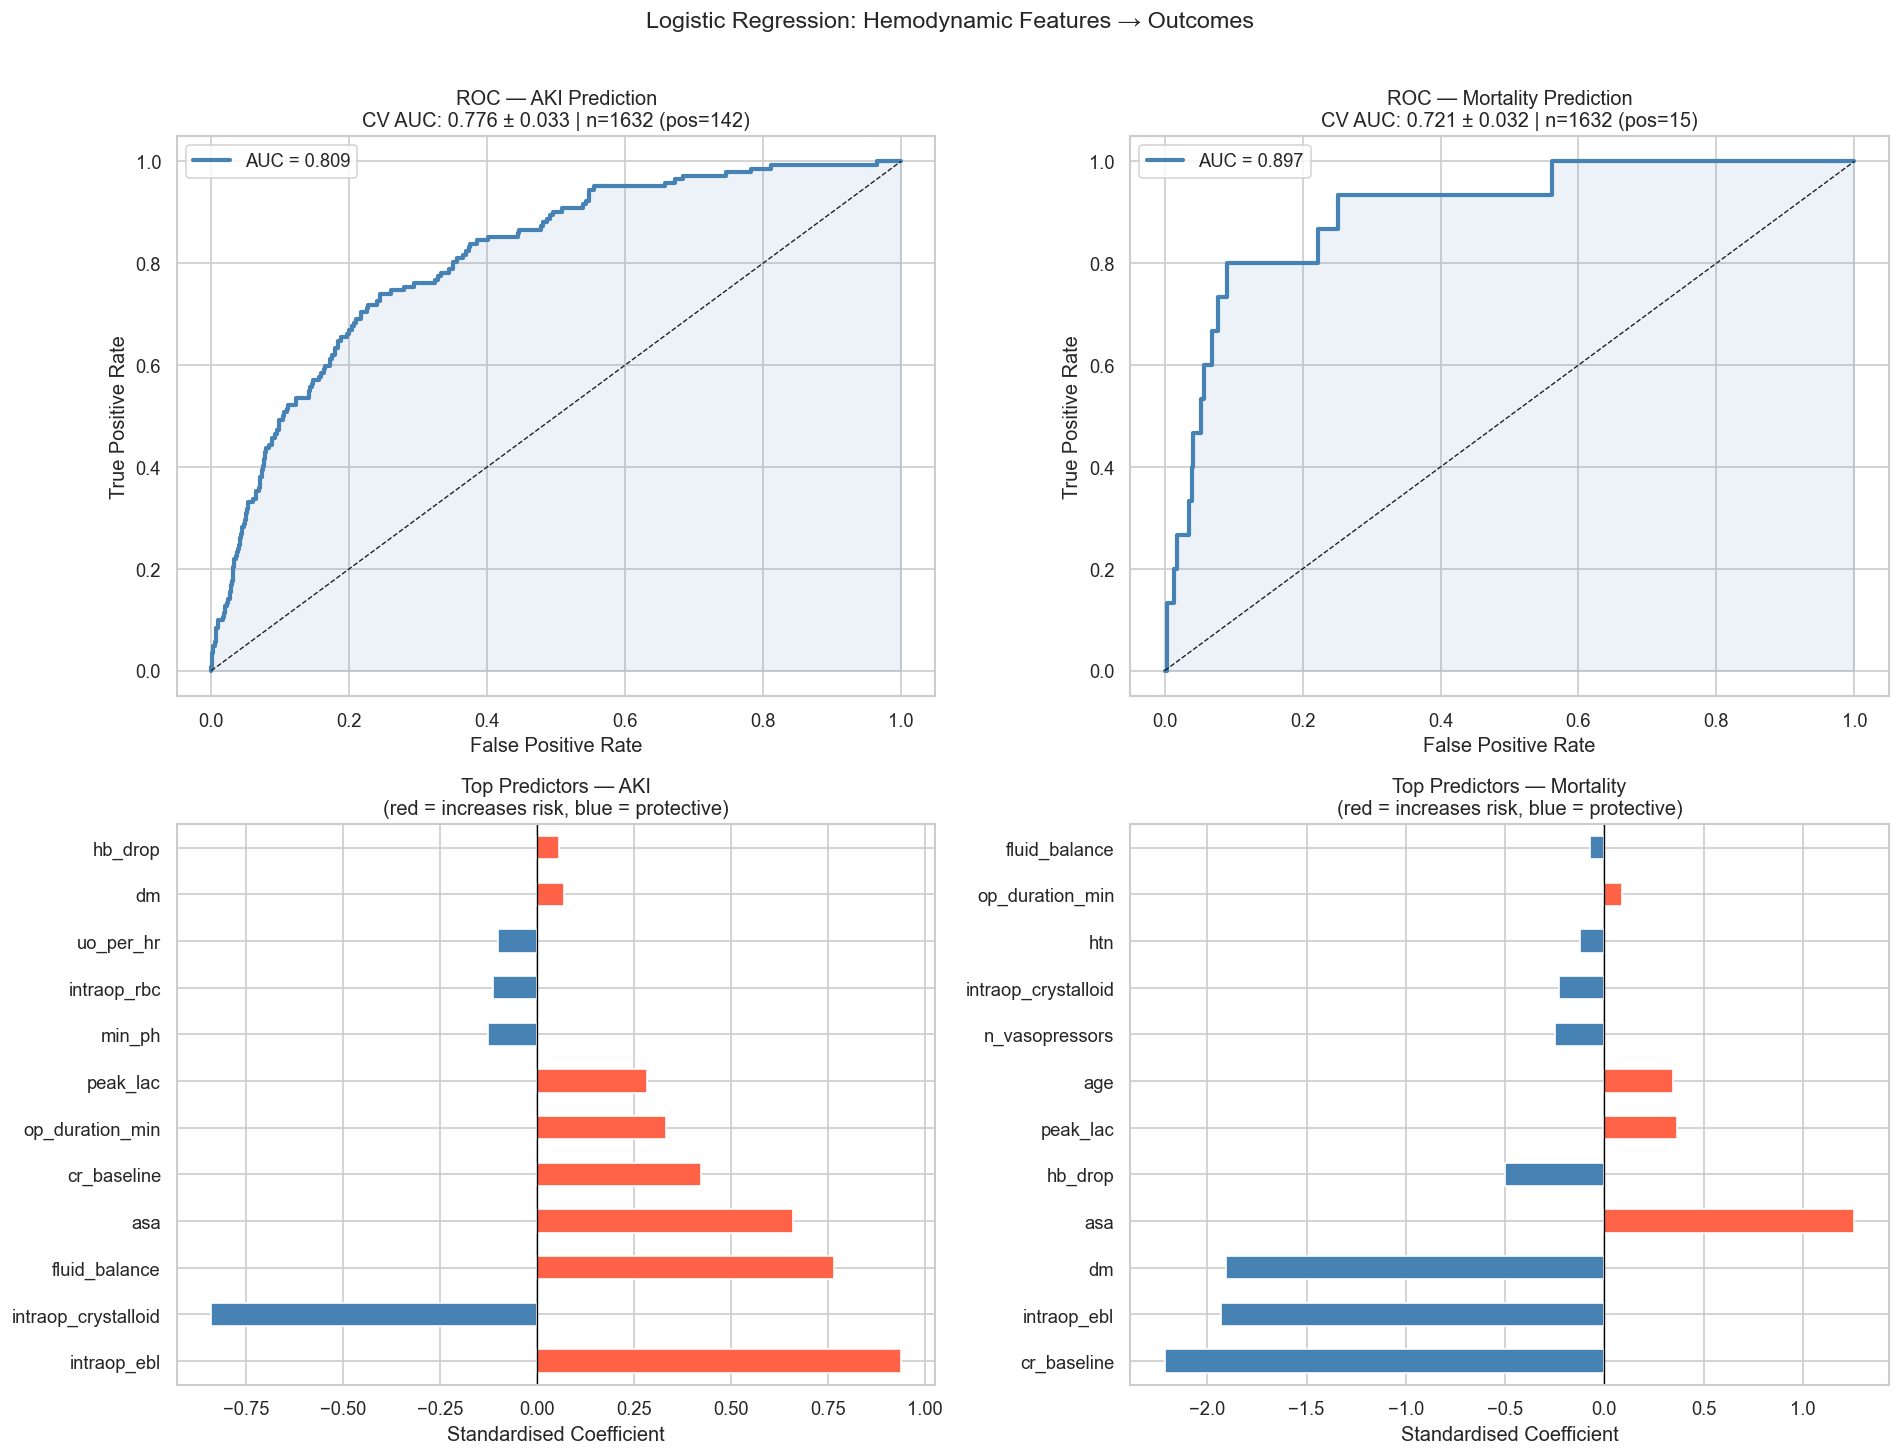

In [16]:
if results:
    n = len(results)
    fig, axes = plt.subplots(2, n, figsize=(8*n, 12))
    if n == 1: axes = [[axes[0]], [axes[1]]]

    for col_i, (target, res) in enumerate(results.items()):
        # ROC curve
        ax = axes[0][col_i]
        ax.plot(res['fpr'], res['tpr'], color='steelblue', linewidth=2.5,
                label=f"AUC = {res['full_auc']:.3f}")
        ax.fill_between(res['fpr'], res['tpr'], alpha=0.1, color='steelblue')
        ax.plot([0,1],[0,1],'k--',linewidth=0.8)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_title(f"ROC — {res['label']} Prediction\n"
                     f"CV AUC: {res['cv_auc']:.3f} ± {res['cv_std']:.3f} | n={res['n']} (pos={res['n_pos']})")
        ax.legend()

        # Feature importance
        ax2 = axes[1][col_i]
        coefs = res['coefs'].head(12)
        colors_c = ['tomato' if c > 0 else 'steelblue' for c in coefs.values]
        coefs.plot(kind='barh', ax=ax2, color=colors_c, edgecolor='white')
        ax2.axvline(0, color='black', linewidth=0.8)
        ax2.set_title(f"Top Predictors — {res['label']}\n(red = increases risk, blue = protective)")
        ax2.set_xlabel('Standardised Coefficient')

    plt.suptitle('Logistic Regression: Hemodynamic Features → Outcomes', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

### How well does the model perform, and what drives it?

**AKI prediction (CV AUC ~0.78):** The model achieves acceptable-to-good discrimination. An AUC of 0.78 means that if you randomly pick one patient who developed AKI and one who did not, the model will correctly assign a higher risk score to the AKI patient about 78% of the time. That is meaningfully better than chance, though far from perfect — consistent with the multifactorial nature of AKI.

**Mortality prediction (CV AUC ~0.72):** Somewhat lower, reflecting the difficulty of predicting a rare event (only 15 deaths in the modelling sample). With so few positive cases, the model has limited "signal" to learn from, and the confidence interval around this AUC is wide.

### Which features matter most?

The horizontal bar charts (bottom row) show the **standardised coefficients** from the logistic regression. Red bars increase risk; blue bars are protective.

For **AKI prediction**, the top drivers are likely:
- **Baseline creatinine** — patients who start with impaired kidney function are more vulnerable
- **Haemoglobin drop** and **blood loss** — surrogates for haemorrhage and reduced oxygen delivery
- **Peak lactate** — direct evidence of tissue hypoperfusion
- **Operation duration** — longer cases mean more cumulative haemodynamic stress

For **mortality prediction**, the pattern may differ slightly, with **ASA score** (a global measure of patient fitness) and **lactate** playing prominent roles.

**The clinical bottom line:** A simple model using routinely available intraoperative data can identify high-risk patients with reasonable accuracy. This is not a replacement for clinical judgement, but it suggests that systematic risk scoring — perhaps automated in real time — could help flag patients who merit closer post-operative surveillance.

## 12. Is urine output really a useful perfusion proxy?

Urine output is one of the oldest and simplest monitors in anaesthesia. A catheter, a collection bag, and a pair of eyes are all you need. But does it actually predict outcomes? We divide patients into quartiles (four equal groups) based on their intraoperative urine output per hour and compare adverse event rates across the groups.

In [17]:
# Clinically meaningful UO groups
cohort['uo_group'] = pd.qcut(
    cohort['uo_per_hr'].rank(method='first'),
    q=4, labels=['Q1 (Low UO)', 'Q2', 'Q3', 'Q4 (High UO)']
)

uo_summary = (
    cohort.groupby('uo_group', observed=True)
    .agg(
        n=('caseid', 'count'),
        uo_median=('uo_per_hr', 'median'),
        mortality_pct=('death_inhosp', lambda x: x.mean() * 100),
        icu_pct=('icu_days', lambda x: (x > 0).mean() * 100),
        aki_pct=('aki_any', lambda x: x.mean() * 100),
        vaso_pct=('vasopressor_any', lambda x: x.mean() * 100),
        lac_median=('peak_lac', 'median'),
    ).round(1)
)
print('Outcomes by Intraoperative Urine Output Quartile:')
print(uo_summary.to_string())

Outcomes by Intraoperative Urine Output Quartile:
                n  uo_median  mortality_pct  icu_pct  aki_pct  vaso_pct  lac_median
uo_group                                                                           
Q1 (Low UO)   931        0.0            2.0     16.6      8.9      46.8         1.0
Q2            931       29.3            0.8     32.5      6.2      65.6         1.2
Q3            931       60.0            0.6     35.0      8.6      69.7         1.3
Q4 (High UO)  931      134.7            1.0     37.8      6.1      71.6         1.2


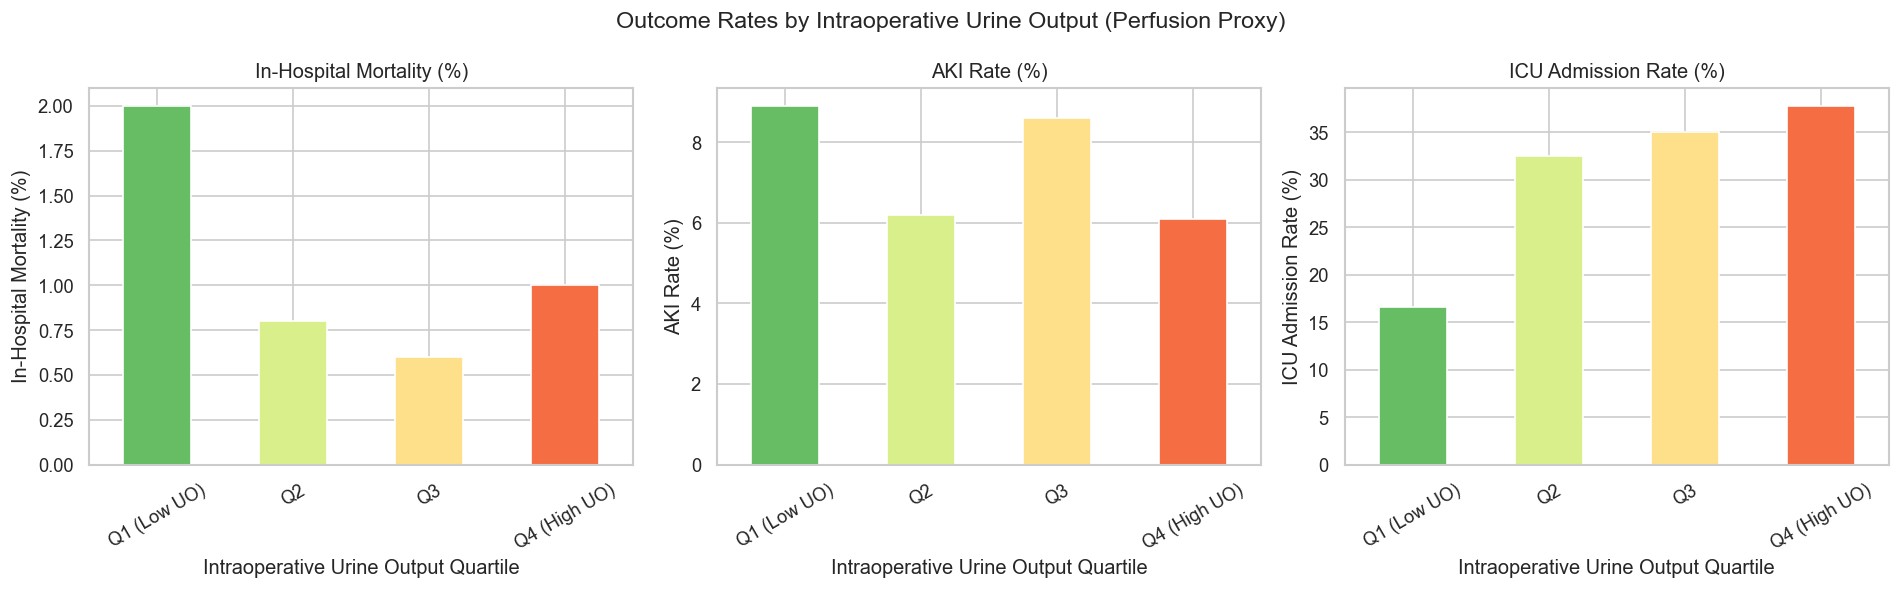

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pal = sns.color_palette('RdYlGn', 4)[::-1]

for ax, (col, title) in zip(axes, [
    ('mortality_pct', 'In-Hospital Mortality (%)'),
    ('aki_pct',       'AKI Rate (%)'),
    ('icu_pct',       'ICU Admission Rate (%)'),
]):
    uo_summary[col].plot(kind='bar', ax=ax, color=pal, edgecolor='white', rot=30)
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.set_xlabel('Intraoperative Urine Output Quartile')

plt.suptitle('Outcome Rates by Intraoperative Urine Output (Perfusion Proxy)', fontsize=14)
plt.tight_layout()
plt.show()

### What do the urine output quartiles reveal?

The results are more nuanced than you might expect:

- **Mortality** is highest in the lowest urine output quartile (Q1), which is consistent with the idea that very low urine output reflects critically poor perfusion. However, the relationship is not perfectly linear — Q4 (high output) also has a slightly higher mortality than Q2–Q3.
- **AKI rates** are highest in Q1 (low output) and Q3, rather than showing a clean dose-response. This suggests that intraoperative urine output alone is an imperfect predictor of post-operative kidney injury — many other factors (pre-existing kidney disease, nephrotoxin exposure, post-operative haemodynamics) contribute.
- **ICU admission** actually *increases* with higher urine output. This is a classic example of **confounding**: patients with higher urine output tend to have longer, more complex operations (which produce more urine simply because the catheter is in for longer), and these same patients are more likely to go to ICU.

**The take-away:** Intraoperative oliguria is a concerning sign, but urine output on its own is a blunt instrument. It is most useful as one piece of a larger puzzle — combined with lactate, blood pressure trends, and the clinical context.

## 13. Does the type of surgery matter? Department-specific haemodynamic profiles

Not all operations are created equal. A brief laparoscopic procedure has a very different haemodynamic profile from an open hepatectomy or a cardiac case. Here we compare the six most common surgical departments in our cohort, examining both the haemodynamic "stress" of each specialty and the corresponding outcome rates.

Hemodynamic profile by surgical department:
                     n  median_ebl  median_uo_hr  vaso_rate  rbc_rate  aki_rate  mortality  icu_rate  median_lac
department                                                                                                      
General surgery   2370       200.0          47.1       72.9      12.0      10.4        1.3      25.9         1.2
Gynecology         188       200.0          58.8       57.4       4.3       4.3        0.0       4.3         0.9
Thoracic surgery  1083       100.0          37.2       43.2       3.1       2.7        0.9      47.2         1.1
Urology             83       300.0           0.0       71.1       2.4      66.7        1.2       4.8         1.2


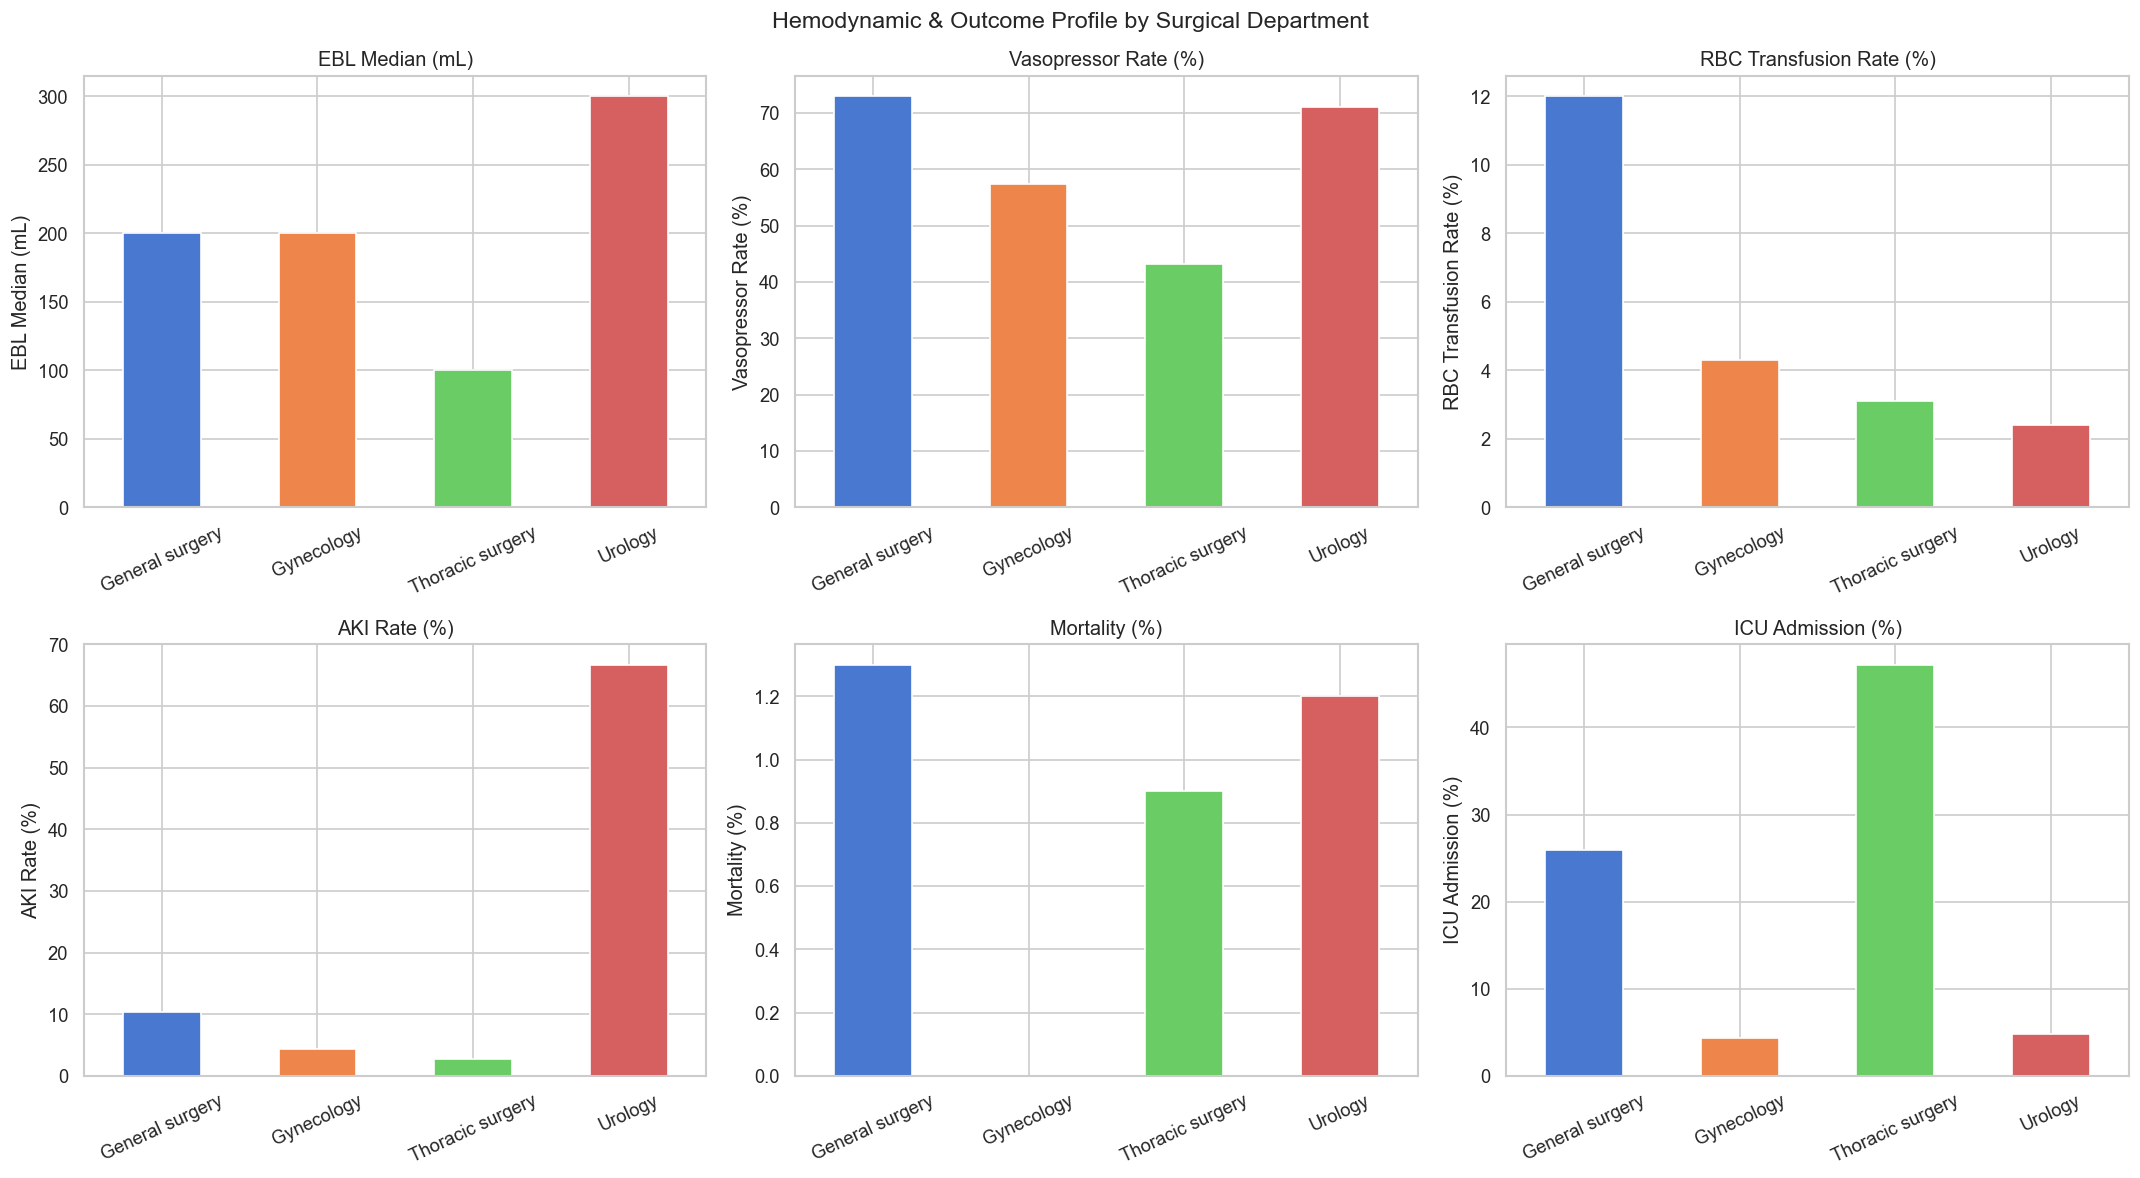

In [19]:
top_depts = cohort['department'].value_counts().head(6).index
dept_hemo = (
    cohort[cohort['department'].isin(top_depts)]
    .groupby('department')
    .agg(
        n=('caseid', 'count'),
        median_ebl=('intraop_ebl', 'median'),
        median_uo_hr=('uo_per_hr', 'median'),
        vaso_rate=('vasopressor_any', lambda x: x.mean() * 100),
        rbc_rate=('rbc_transfused', lambda x: x.mean() * 100),
        aki_rate=('aki_any', lambda x: x.mean() * 100),
        mortality=('death_inhosp', lambda x: x.mean() * 100),
        icu_rate=('icu_days', lambda x: (x > 0).mean() * 100),
        median_lac=('peak_lac', 'median'),
    ).round(1)
)
print('Hemodynamic profile by surgical department:')
print(dept_hemo.to_string())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = [('median_ebl','EBL Median (mL)'), ('vaso_rate','Vasopressor Rate (%)'),
           ('rbc_rate','RBC Transfusion Rate (%)'), ('aki_rate','AKI Rate (%)'),
           ('mortality','Mortality (%)'), ('icu_rate','ICU Admission (%)')]
pal_dept = sns.color_palette('muted', len(top_depts))

for ax, (col, title) in zip(axes.flatten(), metrics):
    dept_hemo[col].plot(kind='bar', ax=ax, color=pal_dept, edgecolor='white', rot=25)
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.set_xlabel('')

plt.suptitle('Hemodynamic & Outcome Profile by Surgical Department', fontsize=14)
plt.tight_layout()
plt.show()

### What do the specialty comparisons show?

The department-level profiles reveal dramatic differences:

- **Blood loss** varies enormously across specialties — some departments have median EBLs many times higher than others, reflecting the inherent nature of the surgery.
- **Vasopressor rates** are highest in specialties performing longer, more invasive procedures — again confirming that haemodynamic instability is largely driven by surgical complexity.
- **AKI and mortality rates** track closely with the haemodynamic burden: departments with higher blood loss, more transfusions, and more vasopressor use also have worse outcomes.

**Why this matters:** When building predictive models or interpreting risk, the type of surgery is an essential piece of context. A "high" blood loss in one specialty may be routine in another. Any clinical decision-support tool would need to account for these baseline differences to be useful in practice.

## 14. Bringing it all together — what have we learned?

This notebook has taken us from raw intraoperative data to a working predictive model. Before we look at the final summary numbers, here are the key messages:

1. **AKI after major surgery is common (7.3%) and consequential** — even mild kidney injury is associated with higher mortality and ICU admission.
2. **The usual suspects matter:** blood loss, vasopressor requirements, lactate, and haemoglobin drop are the strongest haemodynamic predictors of adverse outcomes. This is reassuring — it means the things anaesthesiologists already pay attention to are genuinely informative.
3. **Combining features is better than any single marker.** Our logistic regression model (CV AUC 0.78 for AKI) meaningfully outperforms any individual feature, because risk is multifactorial.
4. **Urine output is useful but imperfect** as a real-time perfusion proxy — it is confounded by case duration and other factors.
5. **Surgical specialty provides essential context** — the same numbers mean very different things in different operations.

The summary statistics below capture the headline numbers from our analysis:

In [20]:
print('=' * 68)
print('HEMODYNAMICS ANALYSIS — KEY FINDINGS')
print('=' * 68)
print(f'ART cohort (SBP+DBP+MBP tracks)  : {len(cohort):,} cases')
print(f'In-hospital mortality             : {cohort["death_inhosp"].mean()*100:.2f}%')
print(f'ICU admission                     : {(cohort["icu_days"]>0).mean()*100:.1f}%')
print()
art_cr = cohort.dropna(subset=['aki'])
for stage in ['Stage 1', 'Stage 2', 'Stage 3']:
    n = (art_cr['aki'] == stage).sum()
    print(f'AKI {stage:8s}              : {n:,} ({n/len(art_cr)*100:.1f}%)')
print()
print(f'Vasopressor use (any)             : {cohort["vasopressor_any"].sum():,} ({cohort["vasopressor_any"].mean()*100:.1f}%)')
print(f'RBC transfusion                   : {cohort["rbc_transfused"].sum():,} ({cohort["rbc_transfused"].mean()*100:.1f}%)')
print(f'Oliguria (UO <30 mL/hr)           : {cohort["oliguria"].sum():,} ({cohort["oliguria"].mean()*100:.1f}%)')
print(f'Lactate >2 mmol/L                 : {cohort["hyperlactataemia"].sum():,} ({cohort["hyperlactataemia"].mean()*100:.1f}%)')
print(f'Acidosis (pH <7.35)               : {cohort["acidosis"].sum():,} ({cohort["acidosis"].mean()*100:.1f}%)')
print(f'High cardiac stress (score ≥2)    : {(cohort["cardiac_stress"]>=2).sum():,} ({(cohort["cardiac_stress"]>=2).mean()*100:.1f}%)')
print()
for target, res in results.items():
    print(f'CV AUC ({res["label"]:12s})          : {res["cv_auc"]:.3f} ± {res["cv_std"]:.3f}')
print('=' * 68)

HEMODYNAMICS ANALYSIS — KEY FINDINGS
ART cohort (SBP+DBP+MBP tracks)  : 3,724 cases
In-hospital mortality             : 1.10%
ICU admission                     : 30.5%

AKI Stage 1               : 144 (5.9%)
AKI Stage 2               : 17 (0.7%)
AKI Stage 3               : 18 (0.7%)

Vasopressor use (any)             : 2,363 (63.5%)
RBC transfusion                   : 328 (8.8%)
Oliguria (UO <30 mL/hr)           : 1,405 (37.7%)
Lactate >2 mmol/L                 : 563 (15.1%)
Acidosis (pH <7.35)               : 971 (26.1%)
High cardiac stress (score ≥2)    : 1,087 (29.2%)

CV AUC (AKI         )          : 0.776 ± 0.033
CV AUC (Mortality   )          : 0.721 ± 0.032
